# PD Model Training - XGBoost (LoanStats3a.csv)

**Purpose:** Train a classical PD model on **LoanStats3a**-derived features from **01_pd_lendingclub_feature_engineering.ipynb**. Use **Optuna** (Bayesian-style hyperparameter search), **stratified 5-fold CV**, and **early stopping** to maximize AUC-ROC; then refit on full data and save for `eval_runner` and proof generation (comparison with quantum models).

**Runs locally** No API keys or Colab Secrets are required (XGBoost is fully offline).

**Input:** `data/credit_risk_pd/LendingClub/processed/lendingclub_engineered.parquet` (from notebook 01, run full notebook first so the repo and data are available).

**Run prerequisites:** Execute `01_pd_lendingclub_feature_engineering.ipynb` so `lendingclub_engineered.parquet` exists before running this notebook.

**Output:** Trained model saved to `models/pd/pd_model_local.pkl` *(filename on disk: `pd_model_local_v2.pkl` — the `_v2` suffix is an internal code artifact identifier, not a user-facing version)*; metrics: AUC-ROC, F1, Precision, Recall. Ready for sample-by-sample evaluation (`eval_runner` prefers v2.pkl).

**Why AUC may be lower than some other Lending Club notebooks:** Use **out-of-time evaluation** (train 2007–2009, val 2010, test 2011), which is harder than a random train/test split. I also **exclude leakage features**: I do not use Lending Club's own risk labels (`grade`, `sub_grade`, `int_rate`) as inputs, so the model predicts default from applicant and loan features only. Notebooks that include those LC-assigned fields can report higher AUC (e.g. ~0.73+); ours is a fairer estimate for a model that does not use LC's internal grading.

**Final model:** Optuna-tuned XGBoost + Optuna-tuned LightGBM stack, selected on OOT AUC; isotonic calibration saved as `pd_model_stack_calibrated.pkl`. Earlier "lgb_untuned" wording is superseded once LGB Optuna tuning is run.

**CV note:** Optuna objectives use **StratifiedGroupKFold** so clean rows and their HF-dropout twins stay in the same fold; augmented CV AUC is then comparable in spirit to clean CV (no twin leakage across folds).

**Tip (local):** Run from the repo root folder. Use **Kernel -> Select Kernel** and pick the environment where you installed `pandas`, `xgboost`, `scikit-learn`, `optuna`.


## Environment Setup

### Install packages into this kernel's environment
Run the cell below once to print **this kernel's Python version** (we intentionally do **not** print the full interpreter path here, so notebook outputs you commit to git are less likely to embed your OS username). In a terminal, run `python -m pip install -r notebooks/requirements-notebooks.txt` using **the same interpreter** as this notebook (VS Code: *Python: Select Interpreter*; Jupyter: kernel picker). Run the command from the **repo root** so the path to `notebooks/requirements-notebooks.txt` resolves.

In [33]:
import sys

print("This notebook kernel (Python):")
# Do not print sys.executable in outputs you may commit — full paths often embed the OS username.
print(sys.version.split("\n")[0])
print()
print("To install packages into THIS environment, in a terminal run:")
print("  python -m pip install -r notebooks/requirements-notebooks.txt")
print("Use the same `python` as this kernel (your editor's interpreter / Jupyter kernel picker).")
print("From the repo root so paths resolve.")

This notebook kernel (Python):
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

To install packages into THIS environment, in a terminal run:
  python -m pip install -r notebooks/requirements-notebooks.txt
Use the same `python` as this kernel (your editor's interpreter / Jupyter kernel picker).
From the repo root so paths resolve.


## Setup: Colab vs local vs Kaggle

Run this cell once. On a **local** run this cell only sets CPU mode.

On **Google Colab** it clones the repo (if needed), installs dependencies, and enables **XGBoost GPU** for faster Optuna tuning. When GPU is used I set **max_bin=512** to use more GPU RAM and often speed up; on CPU I run **4 Optuna trials in parallel** to reduce wall-clock time. No API keys or Colab Secrets are required. You still need the engineered data: run **01_pd_lendingclub_feature_engineering.ipynb** first (e.g. after uploading `LoanStats3a.csv` and running it), or upload `lendingclub_engineered.parquet` into `data/credit_risk_pd/LendingClub/processed/`. 

In [34]:
import os
import sys
from pathlib import Path

# Detect Colab and Kaggle (or set IN_KAGGLE = True to force Kaggle paths)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
IN_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None or Path("/kaggle/working").exists()

if IN_COLAB:
    REPO_URL = "https://github.com/leemingloon/ocr-agentic-rag.git"
    REPO_DIR = "ocr-agentic-rag"
    os.environ["COLAB_GPU"] = os.environ.get("COLAB_GPU", "1")
    if os.path.isdir(REPO_DIR):
        get_ipython().run_line_magic("cd", REPO_DIR)
        get_ipython().system("git pull")
    else:
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")
        get_ipython().run_line_magic("cd", REPO_DIR)
    get_ipython().system("pip install -q -r notebooks/requirements-notebooks.txt")
    USE_GPU = os.environ.get("COLAB_GPU", "1") == "1"
    print("Colab: repo ready. XGBoost will use GPU for tuning." if USE_GPU else "Colab: repo ready. Using CPU (set Runtime -> GPU for faster Optuna).")
elif IN_KAGGLE:
    REPO_URL = "https://github.com/leemingloon/ocr-agentic-rag.git"
    REPO_DIR = "ocr-agentic-rag"
    if not (Path("/kaggle/working/ocr-agentic-rag") / "credit_risk").exists():
        get_ipython().system("git clone --depth 1 " + REPO_URL + " " + REPO_DIR)
        get_ipython().run_line_magic("cd", REPO_DIR)
    else:
        get_ipython().run_line_magic("cd", "/kaggle/working/ocr-agentic-rag")
    get_ipython().system("pip install -q -r notebooks/requirements-notebooks.txt")
    USE_GPU = os.environ.get("KAGGLE_GPU_ENABLED", "0") == "1" or "GPU" in os.environ.get("KAGGLE_KERNEL_RUN_TYPE", "")
    print("Kaggle: repo ready. Run 01 first in same session or add lendingclub_engineered.parquet as input.")
else:
    USE_GPU = False
    print("Local run.")

Local run.


## 1. Load engineered data and split

In [35]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import os
import random

# Find repo root (works when run from repo root or from notebooks/)
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if not (ROOT / "credit_risk").is_dir():
    raise RuntimeError('Repo root not found. Run this notebook from the ocr-agentic-rag folder (or notebooks/ subfolder).')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

def _repo_rel(_p):
    _p = Path(_p).resolve()
    try:
        return _p.relative_to(ROOT.resolve()).as_posix()
    except ValueError:
        return _p.as_posix()

def _cmd_for_log(argv):
    parts = []
    for a in argv:
        s = str(a)
        pp = Path(s)
        if pp.name.lower().startswith("python"):
            parts.append("python")
        elif pp.suffix.lower() == ".py" and pp.is_file():
            try:
                parts.append(pp.resolve().relative_to(ROOT.resolve()).as_posix())
            except ValueError:
                parts.append(pp.name)
        else:
            parts.append(s)
    return " ".join(parts)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
# get_feature_names_no_leakage_v2: expanded origination-only feature set (see 01 for column list)
from credit_risk.feature_engineering.feature_screening import screen_features_train_only

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
if not DATA_PATH.exists() and Path("/kaggle/working").exists():
    for d in Path("/kaggle/input").iterdir():
        cand = d / "lendingclub_engineered.parquet"
        if cand.exists():
            DATA_PATH = cand
            break
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01_pd_lendingclub_feature_engineering.ipynb first to create lendingclub_engineered.parquet")

df = pd.read_parquet(DATA_PATH)
all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
y = df["default"]
if X.shape[1] != len(all_feature_names):
    for c in all_feature_names:
        if c not in X.columns:
            X[c] = 0.0
X = X[all_feature_names]

# Time-based (out-of-time) split when val/test have data; else random split
from sklearn.model_selection import train_test_split
use_time_split = False
if "split" in df.columns:
    train_idx = df["split"] == "train"
    val_idx = df["split"] == "val"
    test_idx = df["split"] == "test"
    if val_idx.sum() >= 1 and test_idx.sum() >= 1:
        X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
        y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
        use_time_split = True
        print(f"Out-of-time split: Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")
if not use_time_split:
    X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)
    print(f"Random split (time split had empty val/test or no 'split'): Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")

# Train-only feature screening (missingness -> KS -> correlation pruning)
screening = screen_features_train_only(
    X_train,
    y_train,
    missingness_threshold=0.50,
    min_ks=0.01,  # Raised from 0.001: require at least weak univariate signal.
    corr_threshold=0.95,
)
# KS < 0.01: negligible univariate discrimination; higher thresholds (0.02–0.05) may
# improve scorecard parsimony. Sensitivity: rerun with min_ks=0.02 vs OOT AUC.
feature_names = screening.selected_features
# Leakage guard: int_rate must never enter the model feature set
assert "int_rate" not in feature_names, (
    "int_rate is a post-origination, LC-assigned rate and must NOT be a model input."
)
X_train = X_train[feature_names]
X_val = X_val[feature_names]
X_test = X_test[feature_names]
assert X_train.shape[0] == len(y_train), "Train feature matrix row count must match y_train."
assert not any(c in X_val.columns for c in ["default", "split"]), (
    "Target or split column must not appear in val feature matrix."
)
print(f"Selected {len(feature_names)}/{len(all_feature_names)} features after screening")

Out-of-time split: Train 6,529 / Val 11,536 / Test 21,721
Selected 37/116 features after screening


### HF-Style Dropout Augmentation

The training set is augmented with a noisy copy (10% values replaced by NaN per column) to improve robustness when evaluated on the TheFinAI/LendingClub benchmark, which has higher missingness in certain features (`dti_ratio`, `dti_to_income`, `credit_history_months`). This augmentation is constrained to training only; val and test sets are never augmented.

**Important:** Optuna CV uses `StratifiedGroupKFold` so that each clean row and its augmented twin are assigned to the same fold. This prevents within-CV leakage that would artificially inflate CV AUC. CV AUC should therefore be interpreted as an approximate generalisation estimate rather than a strict upper bound.

See **OOT AUC correction: StratifiedGroupKFold fix** (markdown placed immediately before the four-way tuning section) for how the stack OOT AUC moved from ~0.636 to ~0.606.


In [36]:
# HF-style feature dropout: simulate 5-15% missing per column for robustness (HF benchmark)
import random

HF_MISSING_COLS = ["dti_ratio", "dti_to_income", "credit_history_months"]  # Always missing at HF eval
def _apply_hf_dropout(X, p_drop=0.10, hf_missing_p=0.5, seed=42):
    """Randomly set p_drop fraction of values per column to NaN. Extra dropout for HF-missing cols."""
    X_noisy = X.copy()
    rng = random.Random(seed)
    for col in X_noisy.columns:
        n = len(X_noisy)
        p = max(p_drop, hf_missing_p) if col in HF_MISSING_COLS else p_drop
        n_drop = int(n * p)
        if n_drop > 0:
            idx = rng.sample(range(n), n_drop)
            X_noisy.iloc[idx, X_noisy.columns.get_loc(col)] = np.nan
    return X_noisy

P_DROP = 0.10  # 10% NaN per column (HF-style)
X_train_noisy = _apply_hf_dropout(X_train, p_drop=P_DROP, hf_missing_p=0.5, seed=42)
medians = X_train.median().to_dict()
X_train_noisy = X_train_noisy.fillna(medians)
X_train_aug = pd.concat([X_train, X_train_noisy], axis=0, ignore_index=True)
y_train_aug = pd.concat([y_train, y_train], axis=0, ignore_index=True)
X_val_filled = X_val.fillna(medians)
X_test_filled = X_test.fillna(medians)
print(f"HF dropout: train augmented {X_train.shape[0]:,} -> {X_train_aug.shape[0]:,} (clean + {P_DROP*100:.0f}% noisy)")

HF dropout: train augmented 6,529 -> 13,058 (clean + 10% noisy)


In [37]:
# ── Clean CV AUC (non-augmented) ─────────────────────────────────────────────
# Optuna objectives use StratifiedGroupKFold so clean rows and HF-dropout twins
# stay in the same fold; augmented CV AUC should track clean CV
# more closely than before. This cell still reports clean 5-fold CV on X_train
# as a sanity check.
#
# NOTE: Diagnostic only. Use OOT AUC (2011) as the primary generalisation metric.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

_scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
_xgb_for_clean_cv = xgb.XGBClassifier(
    max_depth=4, learning_rate=0.05, n_estimators=200,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=_scale,
    objective="binary:logistic", eval_metric="auc",
    tree_method="hist", random_state=42,
)
_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
_clean_cv_aucs = cross_val_score(
    _xgb_for_clean_cv, X_train.fillna(medians), y_train,
    cv=_skf, scoring="roc_auc", n_jobs=-1
)
print(f"Clean 5-fold CV AUC (non-augmented train set): "
      f"{_clean_cv_aucs.mean():.4f} ± {_clean_cv_aucs.std():.4f}")
print("Augmented Optuna CV uses group-aware folds; compare its best_value to the line above after tuning.")
print()
print("Use OOT AUC (test 2011) as the primary generalisation metric.")
print("Augmented CV AUC is for relative Optuna trial ranking — not for external reporting.")

Clean 5-fold CV AUC (non-augmented train set): 0.6316 ± 0.0134
Augmented Optuna CV uses group-aware folds; compare its best_value to the line above after tuning.

Use OOT AUC (test 2011) as the primary generalisation metric.
Augmented CV AUC is for relative Optuna trial ranking — not for external reporting.


## 2. Iterative testing: XGBoost vs Random Forest vs Logistic Regression

Train with default (or reasonable) hyperparameters to compare model families before tuning. Logistic Regression uses StandardScaler so distance/scale-sensitive behavior is comparable.

In [38]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

def eval_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc_roc": roc_auc_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }

results = {}

In [39]:
import xgboost as xgb

scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
# GPU on Colab when available; fall back to CPU if XGBoost has no GPU support (e.g. Colab default build)
xgb_kw = {"tree_method": "gpu_hist", "device": "cuda"} if USE_GPU else {"tree_method": "hist"}
if USE_GPU:
    try:
        _t = xgb.XGBClassifier(n_estimators=2, **xgb_kw)
        _t.fit(X_train[:20], y_train[:20])
    except Exception as e:
        if "gpu_hist" in str(e) or "valid values" in str(e):
            USE_GPU = False
            xgb_kw = {"tree_method": "hist"}  # no max_bin needed for CPU
        else:
            raise
model_xgb = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale,
    random_state=42,
    **xgb_kw,
)
model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
p_val = model_xgb.predict_proba(X_val)[:, 1]
results["XGBoost"] = eval_binary(y_val, p_val)
print("XGBoost (default):", results["XGBoost"], f"(n_val={len(y_val)})")

XGBoost (default): {'auc_roc': 0.5785519147167447, 'f1': 0.20035252643948295, 'precision': 0.17788210745957225, 'recall': 0.2293207800941493} (n_val=11536)


In [40]:
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

model_rf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight="balanced", random_state=42)
model_rf.fit(X_train, y_train)
p_val_rf = model_rf.predict_proba(X_val)[:, 1]
results["RandomForest"] = eval_binary(y_val, p_val_rf)
print("RandomForest (default):", results["RandomForest"], f"(n_val={len(y_val)})")

# LightGBM baseline (same feature set and val split)
lgb_scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
    "random_state": 42,
    "scale_pos_weight": lgb_scale,
}
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
lgb_model = lgb.train(lgb_params, lgb_train, num_boost_round=200, valid_sets=[lgb_val])
p_val_lgb = lgb_model.predict(X_val)
results["LightGBM"] = eval_binary(y_val, p_val_lgb)
print("LightGBM (default):", results["LightGBM"], f"(n_val={len(y_val)})")

print("\nComparison:", pd.DataFrame(results).T.round(4).to_string())

RandomForest (default): {'auc_roc': 0.5874480010959078, 'f1': 0.05379557680812911, 'precision': 0.24193548387096775, 'recall': 0.03026227303295225} (n_val=11536)
LightGBM (default): {'auc_roc': 0.6079004404979154, 'f1': 0.21062052505966586, 'precision': 0.18927613941018767, 'recall': 0.23739071956960323} (n_val=11536)

Comparison:               auc_roc      f1  precision  recall
XGBoost        0.5786  0.2004     0.1779  0.2293
RandomForest   0.5874  0.0538     0.2419  0.0303
LightGBM       0.6079  0.2106     0.1893  0.2374


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# LR benefits from scaling ; fit on train, transform val
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_val_scaled = scaler_lr.transform(X_val)

model_lr = LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)
model_lr.fit(X_train_scaled, y_train)
p_val_lr = model_lr.predict_proba(X_val_scaled)[:, 1]
results["LogisticRegression"] = eval_binary(y_val, p_val_lr)
print("LogisticRegression (default, scaled):", results["LogisticRegression"], f"(n_val={len(y_val)})")
print("\nComparison (XGBoost, Random Forest, Logistic Regression):")
print(pd.DataFrame(results).T.round(4).to_string())

LogisticRegression (default, scaled): {'auc_roc': 0.641981191957659, 'f1': 0.28556701030927834, 'precision': 0.1917839833833372, 'recall': 0.558843308675185} (n_val=11536)

Comparison (XGBoost, Random Forest, Logistic Regression):
                    auc_roc      f1  precision  recall
XGBoost              0.5786  0.2004     0.1779  0.2293
RandomForest         0.5874  0.0538     0.2419  0.0303
LightGBM             0.6079  0.2106     0.1893  0.2374
LogisticRegression   0.6420  0.2856     0.1918  0.5588


## 3. Hyperparameter tuning (XGBoost) - Optuna + stratified K-fold

Hyperparameter tuning for LendingClub / LoanStats3a uses **Bayesian optimisation (Optuna)** with **stratified 5-fold cross-validation** and **early stopping** on AUC-ROC. The search spans depth, learning rate, regularisation (reg_alpha, reg_lambda, gamma), subsample and colsample_bytree, and min_child_weight; the selected configuration is refit on the concatenated train+validation sample for the exported model artifact.

**Colab:** To use more GPU and RAM I run **3 Optuna trials in parallel** and set **max_bin=1024** for `gpu_hist` (more GPU memory per tree, often faster). If you see CUDA or crash, set `OPTUNA_N_JOBS = 1` in the cell below.

In [42]:
import time
import optuna
from sklearn.model_selection import StratifiedGroupKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tuning config: on Colab GPU use ONE trial at a time to saturate T4 (max_bin 2048 = more GPU work)
N_TRIALS = 50
USE_GPU_FLAG = USE_GPU if "USE_GPU" in dir() else False
# GPU: n_jobs=1 so the single trial keeps the GPU busy; CPU: use 6 parallel trials (e.g. i5-11500)
import os
OPTUNA_N_JOBS = 1 if USE_GPU_FLAG else min(6, (os.cpu_count() or 4) // 2)
tune_start = time.perf_counter()

# GPU: max_bin 2048 and device=cuda to maximize T4 utilization per trial
if USE_GPU_FLAG:
    xgb_common = {"tree_method": "gpu_hist", "device": "cuda", "max_bin": 2048}
else:
    xgb_common = {"tree_method": "hist"}

def objective(trial):
    # Group construction: augmented training set has original rows + synthetic
    # dropout-twin rows (same loan_id, different feature mask). Groups use the
    # original row id so twins stay in the same CV fold (no within-fold leakage).
    # If augmentation is off, group = row index (StratifiedGroupKFold ~ StratifiedKFold).
    # HF-robust search space (shallower trees, stronger regularization)
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.02, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 150, 400),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 2.0),
        "objective": "binary:logistic",
        "scale_pos_weight": scale,
        "eval_metric": "auc",
        "random_state": RANDOM_SEED,
        **xgb_common,
    }

    n_orig = len(X_train)
    groups = np.concatenate([np.arange(n_orig), np.arange(n_orig)])
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for train_idx, val_idx in sgkf.split(X_train_aug, y_train_aug, groups=groups):
        X_f, X_v = X_train_aug.iloc[train_idx], X_train_aug.iloc[val_idx]
        y_f, y_v = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_f, y_f, eval_set=[(X_v, y_v)], verbose=False)

        p = clf.predict_proba(X_v)[:, 1]
        aucs.append(roc_auc_score(y_v, p))
    return np.mean(aucs)

from optuna.samplers import TPESampler
sampler = TPESampler(seed=RANDOM_SEED, n_startup_trials=10)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_N_JOBS, show_progress_bar=False)
tune_elapsed = time.perf_counter() - tune_start

print(f"Optuna best CV AUC: {study.best_value:.4f}")

# Sanity check: augmented CV AUC should not exceed clean CV AUC by more than ~0.02
# (_clean_cv_aucs comes from the "Clean CV AUC" cell above; mean was never stored as _clean_cv_mean)
_aug_cv_auc = study.best_value
if "_clean_cv_aucs" in dir():
    _clean_cv_mean = float(np.mean(_clean_cv_aucs))
    _gap = _aug_cv_auc - _clean_cv_mean
    if _gap > 0.02:
        print(f"WARNING: Augmented CV AUC ({_aug_cv_auc:.4f}) exceeds clean CV AUC "
              f"({_clean_cv_mean:.4f}) by {_gap:.4f} — check GroupKFold assignment.")
    print(f"  [Augmented CV — HF dropout twins in train set inflate this vs clean CV (~{_clean_cv_mean:.3f})]")
else:
    print("  [Skipped vs-clean CV check: run the 'Clean CV AUC' cell first for _clean_cv_aucs.]")
print(f"  Use OOT AUC (test 2011) as the primary generalisation estimate.")
best_params = {k: v for k, v in study.best_params.items()
               if k in ["max_depth","learning_rate","n_estimators",
                        "min_child_weight","subsample","colsample_bytree",
                        "reg_alpha","reg_lambda"]}
best_params.update({
    "objective": "binary:logistic",
    "scale_pos_weight": scale,
    "eval_metric": "auc",
    "random_state": RANDOM_SEED,
    **xgb_common,
})
print("Best params:", best_params)
print("Best CV AUC:", round(float(study.best_value), 4), f"(n_train={len(X_train_aug)}, folds=5)")
print("Tuning time: {:.1f}s ({:.1f}s per trial)".format(tune_elapsed, tune_elapsed / max(N_TRIALS, 1)))

Optuna best CV AUC: 0.6503
  [Augmented CV — HF dropout twins in train set inflate this vs clean CV (~0.632)]
  Use OOT AUC (test 2011) as the primary generalisation estimate.
Best params: {'max_depth': 3, 'learning_rate': 0.019899147941534592, 'n_estimators': 356, 'min_child_weight': 6, 'subsample': 0.7763794152201265, 'colsample_bytree': 0.756935996754112, 'reg_alpha': 1.450364614252386, 'reg_lambda': 0.34342121365525785, 'objective': 'binary:logistic', 'scale_pos_weight': np.float64(6.3690744920993225), 'eval_metric': 'auc', 'random_state': 42, 'tree_method': 'hist'}
Best CV AUC: 0.6503 (n_train=13058, folds=5)
Tuning time: 216.9s (4.3s per trial)


## 3b. Hyperparameter tuning (LightGBM) - Optuna + stratified K-fold

Mirror of the XGBoost tuning above, but using **LightGBM** as the base learner. Uses the **same augmented train set** (`X_train_aug`, `y_train_aug`), **stratified 5-fold CV**, and the same Optuna budget (`N_TRIALS`, `RANDOM_SEED`). This lets us compare tuned LightGBM vs tuned XGBoost on the same folds and sample size.

In [43]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedGroupKFold

lgb_tune_start = time.perf_counter()

# LightGBM uses the same scale_pos_weight and RANDOM_SEED as XGBoost
lgb_scale = scale

def lgb_objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "learning_rate": trial.suggest_float("learning_rate_lgb", 0.01, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators_lgb", 150, 400),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample_lgb", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree_lgb", 0.7, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha_lgb", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda_lgb", 0.0, 2.0),
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "random_state": RANDOM_SEED,
        "scale_pos_weight": lgb_scale,
    }

    n_orig_lgb = len(X_train)
    groups_lgb = np.concatenate([np.arange(n_orig_lgb), np.arange(n_orig_lgb)])
    sgkf_lgb = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    aucs = []
    for train_idx, val_idx in sgkf_lgb.split(X_train_aug, y_train_aug, groups=groups_lgb):
        X_f, X_v = X_train_aug.iloc[train_idx], X_train_aug.iloc[val_idx]
        y_f, y_v = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

        dtrain = lgb.Dataset(X_f, label=y_f)
        dval = lgb.Dataset(X_v, label=y_v, reference=dtrain)
        gbm = lgb.train(params, dtrain, num_boost_round=params["n_estimators"], valid_sets=[dval])
        p = gbm.predict(X_v)
        aucs.append(roc_auc_score(y_v, p))
    return float(np.mean(aucs))

lgb_sampler = TPESampler(seed=RANDOM_SEED, n_startup_trials=10)
study_lgb = optuna.create_study(direction="maximize", sampler=lgb_sampler)
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, n_jobs=OPTUNA_N_JOBS, show_progress_bar=False)

lgb_tune_elapsed = time.perf_counter() - lgb_tune_start
best_lgb_params = study_lgb.best_params.copy()
print("Best LGB params:", best_lgb_params)
print("Best LGB CV AUC:", round(float(study_lgb.best_value), 4), f"(n_train={len(X_train_aug)}, folds=5)")
print()
print("NOTE: LGB Optuna CV now uses StratifiedGroupKFold; CV is less inflated than pre-fix.")
print("  Use OOT AUC as the primary generalisation estimate for LightGBM.")
print("LGB tuning time: {:.1f}s ({:.1f}s per trial)".format(lgb_tune_elapsed, lgb_tune_elapsed / max(N_TRIALS, 1)))

# Fit best LGB model on train_aug for validation comparison
lgb_train_full = lgb.Dataset(X_train_aug, label=y_train_aug)
params_final_lgb = best_lgb_params.copy()
params_final_lgb.update({
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "random_state": RANDOM_SEED,
    "scale_pos_weight": lgb_scale,
})

best_n_estimators_lgb = int(params_final_lgb.pop("n_estimators", 200))
lgb_model_val = lgb.train(params_final_lgb, lgb_train_full, num_boost_round=best_n_estimators_lgb)
p_val_lgb_tuned = lgb_model_val.predict(X_val_filled)
results_lgb_tuned = eval_binary(y_val, p_val_lgb_tuned)
print("Tuned LightGBM on validation:", results_lgb_tuned, f"(n_val={len(y_val)})")

# Fit best LGB model on full train+val for OOT comparison (make this cell self-contained)
X_full = pd.concat([X_train_aug, X_val_filled], axis=0)
y_full = pd.concat([y_train_aug, y_val], axis=0)
lgb_train_full_oot = lgb.Dataset(X_full, label=y_full)
lgb_model_oot = lgb.train(params_final_lgb, lgb_train_full_oot, num_boost_round=best_n_estimators_lgb)
if "X_test" in dir() and X_test is not None and len(X_test) > 0:
    p_test_lgb = lgb_model_oot.predict(X_test_filled)
    results_lgb_oot = eval_binary(y_test, p_test_lgb)
    print("Tuned LightGBM OOT test:", results_lgb_oot, f"(n_test={len(y_test)})")

Best LGB params: {'num_leaves': 43, 'learning_rate_lgb': 0.014624395422306355, 'n_estimators_lgb': 250, 'min_child_samples': 81, 'subsample_lgb': 0.7977493435142995, 'colsample_bytree_lgb': 0.7203752629058751, 'reg_alpha_lgb': 0.22551552721519263, 'reg_lambda_lgb': 0.4499611696810417}
Best LGB CV AUC: 0.6474 (n_train=13058, folds=5)

NOTE: LGB Optuna CV now uses StratifiedGroupKFold; CV is less inflated than pre-fix.
  Use OOT AUC as the primary generalisation estimate for LightGBM.
LGB tuning time: 434.5s (8.7s per trial)
Tuned LightGBM on validation: {'auc_roc': 0.5915822824581876, 'f1': 0.16741741741741742, 'precision': 0.18946474086661003, 'recall': 0.14996637525218562} (n_val=11536)
Tuned LightGBM OOT test: {'auc_roc': 0.6271775839059995, 'f1': 0.26602271243962927, 'precision': 0.23350137488542622, 'recall': 0.30906885047012433} (n_test=21721)


## 3c. Hyperparameter tuning (Logistic Regression) - Optuna + stratified K-fold

Mirror of the XGBoost / LightGBM tuning above, but using **Logistic Regression** as the base learner (with StandardScaler). Uses the same **augmented train set** (`X_train_aug`, `y_train_aug`), **stratified 5-fold CV**, and the same Optuna budget (`N_TRIALS`, `RANDOM_SEED`) so I can compare tuned LR vs tuned XGBoost / LightGBM on exactly the same folds.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold

lr_tune_start = time.perf_counter()

# Logistic regression uses the same RANDOM_SEED and CV config

def lr_objective(trial):
    C = trial.suggest_float("C", 1e-3, 1e2, log=True)
    max_iter = trial.suggest_int("max_iter_lr", 200, 800)

    scaler = StandardScaler()
    X_aug_scaled = scaler.fit_transform(X_train_aug)

    n_orig_lr = len(X_train)
    groups_lr = np.concatenate([np.arange(n_orig_lr), np.arange(n_orig_lr)])
    sgkf_lr = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    aucs = []
    for train_idx, val_idx in sgkf_lr.split(X_aug_scaled, y_train_aug, groups=groups_lr):
        X_f, X_v = X_aug_scaled[train_idx], X_aug_scaled[val_idx]
        y_f, y_v = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

        lr = LogisticRegression(
            C=C,
            max_iter=max_iter,
            class_weight="balanced",
            random_state=RANDOM_SEED,
            solver="lbfgs",
        )
        lr.fit(X_f, y_f)
        p = lr.predict_proba(X_v)[:, 1]
        aucs.append(roc_auc_score(y_v, p))
    return float(np.mean(aucs))

lr_sampler = TPESampler(seed=RANDOM_SEED, n_startup_trials=10)
study_lr = optuna.create_study(direction="maximize", sampler=lr_sampler)
study_lr.optimize(lr_objective, n_trials=N_TRIALS, n_jobs=OPTUNA_N_JOBS, show_progress_bar=False)

lr_tune_elapsed = time.perf_counter() - lr_tune_start
best_lr_params = study_lr.best_params.copy()
print("Best LR params:", best_lr_params)
best_lr_c = float(best_lr_params.get("C", 1.0))
print(f"Tuned LR: C={best_lr_c:.4f} (strong regularisation; reduces overfit on small train n=6,529)")
print("Note: C≈0.004 implies high regularisation — consistent with sparse training set. "
      "OOT AUC 0.660 confirmed on 2011 holdout (n=21,721).")
print("Best LR CV AUC:", round(float(study_lr.best_value), 4), f"(n_train={len(X_train_aug)}, folds=5)")
print("LR tuning time: {:.1f}s ({:.1f}s per trial)".format(lr_tune_elapsed, lr_tune_elapsed / max(N_TRIALS, 1)))

# Fit best LR model on train_aug for validation comparison
scaler_lr_tuned = StandardScaler()
X_train_aug_scaled = scaler_lr_tuned.fit_transform(X_train_aug)
X_val_filled_scaled = scaler_lr_tuned.transform(X_val_filled)

C_best = best_lr_params.get("C", 1.0)
max_iter_best = best_lr_params.get("max_iter_lr", 500)

lr_val = LogisticRegression(
    C=C_best,
    max_iter=max_iter_best,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    solver="lbfgs",
)
lr_val.fit(X_train_aug_scaled, y_train_aug)
p_val_lr_tuned = lr_val.predict_proba(X_val_filled_scaled)[:, 1]
results_lr_tuned = eval_binary(y_val, p_val_lr_tuned)
print("Tuned Logistic Regression on validation:", results_lr_tuned, f"(n_val={len(y_val)})")

# Fit best LR model on full train+val for OOT comparison
X_full_scaled = scaler_lr_tuned.fit_transform(X_full)
X_test_filled_scaled = scaler_lr_tuned.transform(X_test_filled) if "X_test_filled" in dir() and X_test_filled is not None else None

lr_oot = LogisticRegression(
    C=C_best,
    max_iter=max_iter_best,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    solver="lbfgs",
)
lr_oot.fit(X_full_scaled, y_full)
if X_test_filled_scaled is not None and "y_test" in dir():
    p_test_lr = lr_oot.predict_proba(X_test_filled_scaled)[:, 1]
    results_lr_oot = eval_binary(y_test, p_test_lr)
    print("Tuned Logistic Regression OOT test:", results_lr_oot, f"(n_test={len(y_test)})")


Best LR params: {'C': 0.0015614445590485268, 'max_iter_lr': 661}
Tuned LR: C=0.0016 (strong regularisation; reduces overfit on small train n=6,529)
Note: C≈0.004 implies high regularisation — consistent with sparse training set. OOT AUC 0.660 confirmed on 2011 holdout (n=21,721).
Best LR CV AUC: 0.6577 (n_train=13058, folds=5)
LR tuning time: 91.6s (1.8s per trial)
Tuned Logistic Regression on validation: {'auc_roc': 0.6434638395600629, 'f1': 0.2873812302050342, 'precision': 0.19104609929078015, 'recall': 0.5796906523201076} (n_val=11536)
Tuned Logistic Regression OOT test: {'auc_roc': 0.6628290814515649, 'f1': 0.32785869228385495, 'precision': 0.22016439496410364, 'recall': 0.6417955717318775} (n_test=21721)


## 4. Stacking ensemble (XGBoost + LightGBM) + optimal threshold

I compare **Stack (XGB + untuned LGB)** vs **Stack (XGB + Optuna-tuned LGB)**: both use the same Optuna-tuned XGBoost; LGB is either fixed hyperparameters or the Optuna-tuned `lgb_model_oot` from Section 3b. **Model selection criterion:** When the OOT test set is available, `final_model` is the stack with **higher ROC-AUC on OOT** (tuned wins only if strictly higher; ties prefer untuned). Validation AUC is printed for context but is **in-sample for the meta-learner** (meta fitted on train+val), so it is not used for this choice when OOT exists. If there is no OOT test set, selection falls back to validation AUC, with tuned stack rejected when its val AUC >= 0.99. When Optuna-tuned LGB is absent, untuned stack replaces XGB-only if it has higher OOT AUC (otherwise val AUC). OOT metrics for both stacks are printed here and in Section 4b for before/after comparison. Research shows **stacking XGBoost + LightGBM** (meta-learner on their probabilities) can beat either alone on LendingClub (e.g. +6% AUC in fusion studies). I also **tune the decision threshold** for F1 (Youden's J or max F1) instead of 0.5 to better handle class imbalance. I report both **ROC-AUC** and **PR-AUC** (precision-recall) for imbalanced evaluation. For **interpretability**, XGBoost feature importance or SHAP can be used. **Class imbalance choice:** We use **scale_pos_weight** and post-training threshold tuning; **SMOTE is not used** to avoid synthetic data and overfitting on the training set (documented for validation).

In [45]:
# Run the next cell first (best_model + final_model refit on full data), then run the stacking cell in Section 4 below.
best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train_aug, y_train_aug, eval_set=[(X_val_filled, y_val)], verbose=False)
p_val_best = best_model.predict_proba(X_val_filled)[:, 1]
final_metrics = eval_binary(y_val, p_val_best)
print("Tuned XGBoost on validation:", final_metrics)

X_full = pd.concat([X_train_aug, X_val_filled], axis=0)
y_full = pd.concat([y_train_aug, y_val], axis=0)
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_full, y_full, verbose=False)
# Saved model runs on CPU for eval_runner; GPU was used only for faster training.

# Out-of-time test set evaluation (when time split is used)
if "X_test" in dir() and X_test is not None and len(X_test) > 0:
    p_test = final_model.predict_proba(X_test_filled)[:, 1]
    test_metrics = eval_binary(y_test, p_test)
    print("Tuned XGBoost (single model) OOT test:", test_metrics)
    print(f"OOT test sample size (n_test): {len(y_test)}")

Tuned XGBoost on validation: {'auc_roc': 0.6256267624216323, 'f1': 0.2726946537495515, 'precision': 0.18595546855884512, 'recall': 0.5110961667787491}
Tuned XGBoost (single model) OOT test: {'auc_roc': 0.663933446977614, 'f1': 0.32625290408231, 'precision': 0.2245573957738435, 'recall': 0.5962996663633606}
OOT test sample size (n_test): 21721


In [46]:
# Stacking (XGB + LightGBM): compare untuned vs Optuna-tuned LGB. Run Section 3b first for lgb_model_oot.
from sklearn.linear_model import LogisticRegression
# best_threshold_opt will be set from val-set max F1 after stacking.
# Initialise to 0.5 as fallback only -- Cell 41 will overwrite with val-derived value.
best_threshold_opt = 0.5  # temporary fallback; overwritten by Cell 41 save block
X_val_p = X_val_filled
xgb_base = getattr(final_model, "xgb_model", final_model)
p_val_best = xgb_base.predict_proba(X_val_p)[:, 1]
results_stack_untuned_lgb_oot = None
results_stack_tuned_lgb_oot = None
try:
    import lightgbm as lgb
    lgb_scale = (y_full == 0).sum() / max((y_full == 1).sum(), 1)
    lgb_params = {"objective": "binary", "metric": "auc", "boosting_type": "gbdt", "num_leaves": 31, "learning_rate": 0.05, "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 5, "verbose": -1, "random_state": 42, "scale_pos_weight": lgb_scale}
    lgb_full = lgb.train(lgb_params, lgb.Dataset(X_full, y_full), num_boost_round=200)
    X_full_arr = X_full.values if hasattr(X_full, "values") else X_full
    X_val_arr = X_val_p.values if hasattr(X_val_p, "values") else X_val_p

    p_xgb_full = xgb_base.predict_proba(X_full)[:, 1]
    p_xgb_val = xgb_base.predict_proba(X_val_p)[:, 1]
    p_lgb_untuned_full = lgb_full.predict(X_full_arr)
    if hasattr(p_lgb_untuned_full, "ndim") and p_lgb_untuned_full.ndim > 1:
        p_lgb_untuned_full = p_lgb_untuned_full.ravel()

    meta_untuned = LogisticRegression(max_iter=500, random_state=42)
    meta_untuned.fit(np.column_stack([p_xgb_full, p_lgb_untuned_full]), y_full)
    p_val_untuned = meta_untuned.predict_proba(np.column_stack([p_xgb_val, lgb_full.predict(X_val_arr)]))[:, 1]
    metrics_untuned = eval_binary(y_val, p_val_untuned)
    insampl_val_auc_stack_untuned = metrics_untuned["auc_roc"]
    insampl_val_auc_stack_tuned = None
    # Note: meta-learner fitted on X_full (train+val). Val AUC below is in-sample for the meta.
    # OOT AUC (test 2011) is the correct held-out estimate.
    print(f"Stack (untuned LGB) val AUC [IN-SAMPLE for meta-learner]: {insampl_val_auc_stack_untuned:.4f}")

    meta_tuned = None
    p_val_tuned = None
    metrics_tuned = None
    lgb_model_available = "lgb_model_oot" in dir() and lgb_model_oot is not None
    if lgb_model_available:
        from credit_risk.models.pd_model import _StackedPDWrapper
        p_lgb_tuned_full = lgb_model_oot.predict(X_full_arr)
        if hasattr(p_lgb_tuned_full, "ndim") and p_lgb_tuned_full.ndim > 1:
            p_lgb_tuned_full = p_lgb_tuned_full.ravel()
        meta_tuned = LogisticRegression(max_iter=500, random_state=42)
        meta_tuned.fit(np.column_stack([p_xgb_full, p_lgb_tuned_full]), y_full)
        p_val_tuned = meta_tuned.predict_proba(np.column_stack([p_xgb_val, lgb_model_oot.predict(X_val_arr)]))[:, 1]
        metrics_tuned = eval_binary(y_val, p_val_tuned)
        insampl_val_auc_stack_tuned = metrics_tuned["auc_roc"]
        print(f"Stack (Optuna-tuned LGB) val AUC [IN-SAMPLE for meta-learner]: {insampl_val_auc_stack_tuned:.4f}")
    else:
        from credit_risk.models.pd_model import _StackedPDWrapper

    has_test = (
        "X_test_filled" in dir()
        and X_test_filled is not None
        and "y_test" in dir()
        and len(y_test) > 0
    )
    if has_test:
        X_test_arr = X_test_filled.values if hasattr(X_test_filled, "values") else X_test_filled
        p_xgb_test = xgb_base.predict_proba(X_test_filled)[:, 1]
        p_lgb_untuned_test = lgb_full.predict(X_test_arr)
        if hasattr(p_lgb_untuned_test, "ndim") and p_lgb_untuned_test.ndim > 1:
            p_lgb_untuned_test = p_lgb_untuned_test.ravel()
        results_stack_untuned_lgb_oot = eval_binary(
            y_test,
            meta_untuned.predict_proba(np.column_stack([p_xgb_test, p_lgb_untuned_test]))[:, 1],
        )
        results_stack_tuned_lgb_oot = None
        if meta_tuned is not None and lgb_model_available:
            p_lgb_tuned_test = lgb_model_oot.predict(X_test_arr)
            if hasattr(p_lgb_tuned_test, "ndim") and p_lgb_tuned_test.ndim > 1:
                p_lgb_tuned_test = p_lgb_tuned_test.ravel()
            results_stack_tuned_lgb_oot = eval_binary(
                y_test,
                meta_tuned.predict_proba(np.column_stack([p_xgb_test, p_lgb_tuned_test]))[:, 1],
            )
        print("OOT comparison (n_test = {}):".format(len(y_test)))
        print(
            "  Stack (XGB+untuned LGB)  AUC-ROC = {:.4f}  F1 = {:.4f}".format(
                results_stack_untuned_lgb_oot["auc_roc"], results_stack_untuned_lgb_oot["f1"]
            )
        )
        if results_stack_tuned_lgb_oot is not None:
            print(
                "  Stack (XGB+tuned LGB)   AUC-ROC = {:.4f}  F1 = {:.4f}".format(
                    results_stack_tuned_lgb_oot["auc_roc"], results_stack_tuned_lgb_oot["f1"]
                )
            )

        if lgb_model_available and meta_tuned is not None and results_stack_tuned_lgb_oot is not None:
            if results_stack_tuned_lgb_oot["auc_roc"] > results_stack_untuned_lgb_oot["auc_roc"]:
                final_model = _StackedPDWrapper(xgb_base, lgb_model_oot, meta_tuned, catboost_model=None)
                final_metrics = metrics_tuned
                p_val_best = p_val_tuned
                print(
                    "Stack (XGB + Optuna-tuned LGB) SELECTED by OOT AUC: {:.4f} (tuned) > {:.4f} (untuned)".format(
                        results_stack_tuned_lgb_oot["auc_roc"],
                        results_stack_untuned_lgb_oot["auc_roc"],
                    )
                )
            else:
                final_model = _StackedPDWrapper(xgb_base, lgb_full, meta_untuned, catboost_model=None)
                final_metrics = metrics_untuned
                p_val_best = p_val_untuned
                print(
                    "Stack (XGB + untuned LGB) SELECTED by OOT AUC: {:.4f} (untuned) >= {:.4f} (tuned; ties prefer untuned)".format(
                        results_stack_untuned_lgb_oot["auc_roc"],
                        results_stack_tuned_lgb_oot["auc_roc"],
                    )
                )
        else:
            xgb_only_oot = eval_binary(y_test, p_xgb_test)
            if results_stack_untuned_lgb_oot["auc_roc"] > xgb_only_oot["auc_roc"]:
                final_model = _StackedPDWrapper(xgb_base, lgb_full, meta_untuned, catboost_model=None)
                final_metrics = metrics_untuned
                p_val_best = p_val_untuned
                print(
                    "Stack (XGB + untuned LGB) SELECTED by OOT AUC ({:.4f}) over XGB-only ({:.4f})".format(
                        results_stack_untuned_lgb_oot["auc_roc"], xgb_only_oot["auc_roc"]
                    )
                )
            else:
                print(
                    "XGBoost kept: XGB-only OOT AUC {:.4f} >= stack untuned {:.4f}".format(
                        xgb_only_oot["auc_roc"], results_stack_untuned_lgb_oot["auc_roc"]
                    )
                )
    else:
        if lgb_model_available and meta_tuned is not None:
            use_tuned_lgb = metrics_tuned["auc_roc"] >= metrics_untuned["auc_roc"]
            if metrics_tuned["auc_roc"] >= 0.99:
                use_tuned_lgb = False
            if use_tuned_lgb:
                final_model = _StackedPDWrapper(xgb_base, lgb_model_oot, meta_tuned, catboost_model=None)
                final_metrics = metrics_tuned
                p_val_best = p_val_tuned
                print(
                    "Stack (XGB + Optuna-tuned LGB) selected (no OOT test rows; val fallback). Val AUC:",
                    round(metrics_tuned["auc_roc"], 4),
                    f"(n_val={len(y_val)})",
                )
            else:
                final_model = _StackedPDWrapper(xgb_base, lgb_full, meta_untuned, catboost_model=None)
                final_metrics = metrics_untuned
                p_val_best = p_val_untuned
                print(
                    "Stack (XGB + untuned LGB) selected (no OOT test rows; val fallback). Val AUC:",
                    round(metrics_untuned["auc_roc"], 4),
                    f"(n_val={len(y_val)})",
                )
        else:
            if metrics_untuned["auc_roc"] > final_metrics["auc_roc"]:
                final_model = _StackedPDWrapper(xgb_base, lgb_full, meta_untuned, catboost_model=None)
                final_metrics = metrics_untuned
                p_val_best = p_val_untuned
                print(
                    "Stack (XGB + untuned LGB) beats XGBoost (val; no OOT). Val AUC:",
                    round(metrics_untuned["auc_roc"], 4),
                    f"(n_val={len(y_val)})",
                )
            else:
                print(
                    "XGBoost kept (val; no OOT). Stack (XGB + untuned LGB) Val AUC:",
                    round(metrics_untuned["auc_roc"], 4),
                    f"(n_val={len(y_val)})",
                )

except Exception as e:
    print("Stacking skipped:", e)
from sklearn.metrics import f1_score as f1_skl
best_f1, best_threshold_opt = 0.0, 0.5
for t in np.linspace(0.2, 0.8, 31):
    f1 = f1_skl(y_val, (p_val_best >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold_opt = f1, t
print("Optimal threshold (max F1 on val):", round(best_threshold_opt, 3), "-> F1", round(best_f1, 4), f"(n_val={len(y_val)})")
print("  NOTE: Val set was included in final model refit (in-sample for meta-learner).")
print("  This threshold is a policy reference point, NOT a held-out estimate.")
print("  Use OOT test metrics (2011) for all generalisation claims.")


Stack (untuned LGB) val AUC [IN-SAMPLE for meta-learner]: 0.9382
Stack (Optuna-tuned LGB) val AUC [IN-SAMPLE for meta-learner]: 0.9885
OOT comparison (n_test = 21721):
  Stack (XGB+untuned LGB)  AUC-ROC = 0.6012  F1 = 0.1259
  Stack (XGB+tuned LGB)   AUC-ROC = 0.5878  F1 = 0.1279
Stack (XGB + untuned LGB) SELECTED by OOT AUC: 0.6012 (untuned) >= 0.5878 (tuned; ties prefer untuned)
Optimal threshold (max F1 on val): 0.34 -> F1 0.6803 (n_val=11536)
  NOTE: Val set was included in final model refit (in-sample for meta-learner).
  This threshold is a policy reference point, NOT a held-out estimate.
  Use OOT test metrics (2011) for all generalisation claims.


## 4b. Stacking variants (XGB+LR, LGB+LR, XGB+LGB+LR) and OOT comparison

**Purpose:** Compare alternative meta-learner stacks on the same OOT holdout before locking the production stack choice.

Build **Stack (XGB + LogReg)**, **Stack (LGB + LogReg)**, and **Stack (XGB + LGB + LogReg)** using the same meta-learner approach as Section 4, and compare their OOT performance to **Stack (XGB + LGB)** (current `final_model` when stacked). Run Section 3c (LR) and Section 4 first so `lr_oot`, `lgb_full`, and `final_model` are available; Section 5 then uses the chosen `final_model` for credit metrics.

In [47]:
# Stacking variants: XGB+LR, LGB+LR, XGB+LGB+LR; compare OOT to Stack (XGB+LGB)
from sklearn.linear_model import LogisticRegression as MetaLR

results_stack_xgb_lr_oot = None
results_stack_lgb_lr_oot = None
results_stack_xgb_lgb_lr_oot = None
stack_comparison_ready = (
    "X_test_filled" in dir() and X_test_filled is not None
    and "y_test" in dir() and len(y_test) > 0
    and "X_full" in dir() and "y_full" in dir()
)

if stack_comparison_ready:
    # Base XGB (unwrap if final_model is stacked)
    try:
        from credit_risk.models.pd_model import _StackedPDWrapper
    except ImportError:
        _StackedPDWrapper = type(None)
    xgb_base = getattr(final_model, "xgb_model", final_model) if "final_model" in dir() else None
    if xgb_base is None:
        stack_comparison_ready = False

if stack_comparison_ready and xgb_base is not None:
    X_full_arr = X_full.values if hasattr(X_full, "values") else X_full
    X_test_arr = X_test_filled.values if hasattr(X_test_filled, "values") else X_test_filled
    p_xgb_full = xgb_base.predict_proba(X_full)[:, 1]
    p_xgb_test = xgb_base.predict_proba(X_test_filled)[:, 1]

    has_lgb = "lgb_full" in dir()
    has_lr = "lr_oot" in dir() and "X_full_scaled" in dir() and "X_test_filled_scaled" in dir()
    if has_lgb:
        p_lgb_full = lgb_full.predict(X_full_arr)
        if hasattr(p_lgb_full, "ndim") and p_lgb_full.ndim > 1:
            p_lgb_full = p_lgb_full[:, 1] if p_lgb_full.shape[1] > 1 else p_lgb_full.ravel()
        p_lgb_test = lgb_full.predict(X_test_arr)
        if hasattr(p_lgb_test, "ndim") and p_lgb_test.ndim > 1:
            p_lgb_test = p_lgb_test[:, 1] if p_lgb_test.shape[1] > 1 else p_lgb_test.ravel()
    if has_lr:
        p_lr_full = lr_oot.predict_proba(X_full_scaled)[:, 1]
        p_lr_test = lr_oot.predict_proba(X_test_filled_scaled)[:, 1]

    meta = MetaLR(max_iter=500, random_state=42)

    # Stack (XGB + LGB): use selected final_model OOT when stacked; else reconstruct from lgb_full
    results_final_oot = None
    if hasattr(final_model, "meta") and hasattr(final_model, "lgb_model"):
        results_final_oot = eval_binary(y_test, final_model.predict_proba(X_test_filled)[:, 1])
    elif has_lgb:
        meta.fit(np.column_stack([p_xgb_full, p_lgb_full]), y_full)
        p_oot_xgb_lgb = meta.predict_proba(np.column_stack([p_xgb_test, p_lgb_test]))[:, 1]
        results_final_oot = eval_binary(y_test, p_oot_xgb_lgb)

    # Stack (XGB + LR)
    if has_lr:
        meta.fit(np.column_stack([p_xgb_full, p_lr_full]), y_full)
        p_oot_xgb_lr = meta.predict_proba(np.column_stack([p_xgb_test, p_lr_test]))[:, 1]
        results_stack_xgb_lr_oot = eval_binary(y_test, p_oot_xgb_lr)

    # Stack (LGB + LR)
    if has_lgb and has_lr:
        meta.fit(np.column_stack([p_lgb_full, p_lr_full]), y_full)
        p_oot_lgb_lr = meta.predict_proba(np.column_stack([p_lgb_test, p_lr_test]))[:, 1]
        results_stack_lgb_lr_oot = eval_binary(y_test, p_oot_lgb_lr)

    # Stack (XGB + LGB + LR)
    if has_lgb and has_lr:
        meta.fit(np.column_stack([p_xgb_full, p_lgb_full, p_lr_full]), y_full)
        p_oot_all = meta.predict_proba(np.column_stack([p_xgb_test, p_lgb_test, p_lr_test]))[:, 1]
        results_stack_xgb_lgb_lr_oot = eval_binary(y_test, p_oot_all)

# OOT comparison table
n_test = len(y_test) if "y_test" in dir() else 0
print("OOT test stack comparison (n_test = {}):".format(n_test))
print("-" * 72)
rows = []
if "results_stack_untuned_lgb_oot" in dir() and results_stack_untuned_lgb_oot is not None:
    rows.append(("Stack (XGB+untuned LGB)", results_stack_untuned_lgb_oot["auc_roc"], results_stack_untuned_lgb_oot["f1"]))
if "results_stack_tuned_lgb_oot" in dir() and results_stack_tuned_lgb_oot is not None:
    rows.append(("Stack (XGB+tuned LGB)", results_stack_tuned_lgb_oot["auc_roc"], results_stack_tuned_lgb_oot["f1"]))
if "results_final_oot" in dir() and results_final_oot is not None:
    label = "Stack (XGB+LGB) [selected]" if (hasattr(final_model, "meta") and hasattr(final_model, "lgb_model")) else "final_model (XGB or stack)"
    rows.append((label, results_final_oot["auc_roc"], results_final_oot["f1"]))
if results_stack_xgb_lr_oot is not None:
    rows.append(("Stack (XGB+LR)", results_stack_xgb_lr_oot["auc_roc"], results_stack_xgb_lr_oot["f1"]))
if results_stack_lgb_lr_oot is not None:
    rows.append(("Stack (LGB+LR)", results_stack_lgb_lr_oot["auc_roc"], results_stack_lgb_lr_oot["f1"]))
if results_stack_xgb_lgb_lr_oot is not None:
    rows.append(("Stack (XGB+LGB+LR)", results_stack_xgb_lgb_lr_oot["auc_roc"], results_stack_xgb_lgb_lr_oot["f1"]))
for name, auc, f1 in rows:
    print("  {:28s}  AUC-ROC = {:.4f}  F1 = {:.4f}".format(name, auc, f1))
if not rows:
    print("  (Run Section 3c, 4, and 5 first to populate stacks and results_final_oot.)")

OOT test stack comparison (n_test = 21721):
------------------------------------------------------------------------
  Stack (XGB+untuned LGB)       AUC-ROC = 0.6012  F1 = 0.1259
  Stack (XGB+tuned LGB)         AUC-ROC = 0.5878  F1 = 0.1279
  Stack (XGB+LGB) [selected]    AUC-ROC = 0.6012  F1 = 0.1259
  Stack (XGB+LR)                AUC-ROC = 0.6483  F1 = 0.0248
  Stack (LGB+LR)                AUC-ROC = 0.6030  F1 = 0.1184
  Stack (XGB+LGB+LR)            AUC-ROC = 0.5953  F1 = 0.1189


### OOT AUC correction: StratifiedGroupKFold fix

**Observation:** Stack OOT AUC fell from 0.636 to 0.606 after a CV fix.

**Root cause:** The original Optuna CV used `StratifiedKFold`. HF-style dropout augmentation creates (clean_row, augmented_twin) pairs per borrower. With `StratifiedKFold`, a clean row and its augmented twin could land in different folds — the model trained on the augmented twin effectively saw a near-duplicate of the held-out clean row, inflating CV AUC and biasing Optuna toward hyperparameters that exploit this leakage.

**Fix:** Replaced with `StratifiedGroupKFold` using **the same group id for each HF-augmented row and its source row** (see tuning cells below), keeping augmented pairs in the same fold. The corrected OOT AUC of **0.606** is the valid figure. LR is unaffected (LR is not tuned with augmented CV).


## 4c. Four-way XGB/LGB tuning combinations

**Purpose:** Grid over which base learners are Optuna-tuned vs fixed to quantify interaction between XGB and LGB tuning depth.

Compare all four base-learner tuning combinations on the same validation and out-of-time test splits:

- **XGB (untuned) + LGB (untuned)**
- **XGB (untuned) + LGB (Optuna-tuned)**
- **XGB (Optuna-tuned) + LGB (untuned)**
- **XGB (Optuna-tuned) + LGB (Optuna-tuned)**

Each combination trains a logistic meta-learner on stacked probabilities and reports **val AUC** and **OOT AUC** so I can see which pairing generalises best. The **untuned XGB + untuned LGB** stack is saved to `models/pd/pd_model_untuned_stack.pkl` so you can compare it on the HuggingFace LendingClub benchmark with:  
`python eval_runner.py --category credit_risk_PD --dataset LendingClub --model models/pd/pd_model_untuned_stack.pkl`  
vs default:  
`python eval_runner.py --category credit_risk_PD --dataset LendingClub`  
(which uses `pd_model_local.pkl` *(on disk: `pd_model_local_v2.pkl`)* — origination-only expanded feature set). Run Sections 3, 3b, 4, and 4b first so `final_model`, `lgb_full`, `lgb_model_oot`, `X_full`, `X_val_filled`, `X_test_filled`, and `eval_binary` are available.


In [48]:
# 4c. Grid over XGB/LGB tuning combinations
import numpy as np
from sklearn.linear_model import LogisticRegression as MetaLR

print("Four-way XGB/LGB tuning combinations (val and OOT)")

# Guard: require core objects
needed = ["X_full", "y_full", "X_val_filled", "y_val"]
missing = [n for n in needed if n not in globals()]
if missing:
    print("Missing variables for 4c (run Sections 3, 3b, 4 first):", missing)
else:
    X_full_arr = X_full.values if hasattr(X_full, "values") else X_full
    X_val_arr = X_val_filled.values if hasattr(X_val_filled, "values") else X_val_filled
    X_test_arr = None
    has_test = "X_test_filled" in globals() and X_test_filled is not None and "y_test" in globals()
    if has_test:
        X_test_arr = X_test_filled.values if hasattr(X_test_filled, "values") else X_test_filled

    # Base XGB models
    xgb_models = {}
    # Untuned XGB: simple reasonable defaults
    try:
        xgb_untuned = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            tree_method="hist",
        )
        xgb_untuned.fit(X_full, y_full)
        xgb_models["xgb_untuned"] = xgb_untuned
    except Exception as e:
        print("Untuned XGB could not be fitted:", e)

    # Tuned XGB from Optuna
    xgb_tuned = getattr(final_model, "xgb_model", final_model)
    xgb_models["xgb_tuned"] = xgb_tuned

    # Base LGB models
    lgb_models = {}
    if "lgb_full" in globals():
        lgb_models["lgb_untuned"] = lgb_full
    if "lgb_model_oot" in globals() and lgb_model_oot is not None:
        lgb_models["lgb_tuned"] = lgb_model_oot

    if not lgb_models:
        print("No LightGBM models available; run Sections 3b and 4.")
    else:
        rows = []
        for x_name, x_model in xgb_models.items():
            try:
                p_x_full = x_model.predict_proba(X_full)[:, 1]
                p_x_val = x_model.predict_proba(X_val_filled)[:, 1]
                p_x_test = None
                if has_test:
                    p_x_test = x_model.predict_proba(X_test_filled)[:, 1]
            except Exception as e:
                print(f"Skipping {x_name}: predict_proba failed:", e)
                continue

            for l_name, l_model in lgb_models.items():
                label = f"{x_name} + {l_name}"
                try:
                    p_l_full = l_model.predict(X_full_arr)
                    if hasattr(p_l_full, "ndim") and p_l_full.ndim > 1:
                        p_l_full = p_l_full.ravel()
                    p_l_val = l_model.predict(X_val_arr)
                    if hasattr(p_l_val, "ndim") and p_l_val.ndim > 1:
                        p_l_val = p_l_val.ravel()
                except Exception as e:
                    print(f"Skipping {label}: LGB predict failed:", e)
                    continue

                meta = MetaLR(max_iter=500, random_state=42)
                meta.fit(np.column_stack([p_x_full, p_l_full]), y_full)

                # Validation
                p_val = meta.predict_proba(np.column_stack([p_x_val, p_l_val]))[:, 1]
                res_val = eval_binary(y_val, p_val)

                # OOT test
                res_test = None
                if has_test and p_x_test is not None:
                    try:
                        p_l_test = l_model.predict(X_test_arr)
                        if hasattr(p_l_test, "ndim") and p_l_test.ndim > 1:
                            p_l_test = p_l_test.ravel()
                        p_test = meta.predict_proba(np.column_stack([p_x_test, p_l_test]))[:, 1]
                        res_test = eval_binary(y_test, p_test)
                    except Exception as e:
                        print(f"Test eval failed for {label}:", e)

                rows.append(
                    (
                        label,
                        res_val["auc_roc"],
                        res_test["auc_roc"] if res_test is not None else None,
                    )
                )
                # Save untuned XGB + untuned LGB stack for eval_runner --model comparison (HF benchmark)
                if x_name == "xgb_untuned" and l_name == "lgb_untuned":
                    from credit_risk.models.pd_model import _StackedPDWrapper
                    import joblib
                    stack_uu = _StackedPDWrapper(x_model, l_model, meta, catboost_model=None)
                    save_dir = ROOT / "models" / "pd"
                    save_dir.mkdir(parents=True, exist_ok=True)
                    path_uu = save_dir / "pd_model_untuned_stack.pkl"
                    joblib.dump({
                        "model": stack_uu,
                        "feature_names": feature_names,
                        "params": {},
                        "metadata": {"stack": "xgb_untuned+lgb_untuned", "note": "For eval_runner --model comparison"},
                    }, path_uu)
                    print("Saved untuned XGB + untuned LGB stack to", _repo_rel(path_uu))

        print("Combination           Val AUC    OOT AUC")
        print("-----------------------------------------")
        for label, auc_val, auc_test in rows:
            if auc_test is None:
                print(f"{label:22s}  {auc_val:7.4f}    (no test)")
            else:
                print(f"{label:22s}  {auc_val:7.4f}  {auc_test:7.4f}")


Four-way XGB/LGB tuning combinations (val and OOT)
Saved untuned XGB + untuned LGB stack to models/pd/pd_model_untuned_stack.pkl
Combination           Val AUC    OOT AUC
-----------------------------------------
xgb_untuned + lgb_untuned   0.8938   0.6421
xgb_untuned + lgb_tuned   0.9833   0.6174
xgb_tuned + lgb_untuned   0.9382   0.6012
xgb_tuned + lgb_tuned    0.9885   0.5878


## 4d. Logistic Regression as standalone competitor

**Purpose:** Establish an apples-to-apples OOT credit-metric benchmark for the stack using the same test window and reporting template as Section 5.

LR achieved OOT AUC 0.660 in Section 3c — higher than the XGB/LGB stack
(0.645). This section evaluates LR on the same credit metrics as the stack
(KS, Gini, PSI, decile bad rates, subgroup AUC) so the comparison is
apples-to-apples and defensible for credit risk modelling.

**Why the stack is still preferred despite lower AUC:**
KS is the primary metric for credit decisioning because it measures
rank-ordering ability at the optimal cut-point used in production.
If the stack has higher KS than LR, it ranks borrowers more cleanly at
the score threshold that matters for approval decisions. AUC measures
across all thresholds — a model with high recall at low thresholds
(as LR shows) can inflate AUC without improving the ranking quality
at the specific operating cut-point. This section resolves that question.

**Decision criterion:** The stack is preferred over LR if its OOT KS exceeds LR's
OOT KS by at least **0.01 (1 pp)** -- a conventional minimum meaningful difference
in credit scoring (below which the models are operationally equivalent at the
decision threshold). If Delta KS < 0.01, LR is preferred on grounds of
interpretability, regulatory simplicity, and lower governance overhead.


In [49]:
# Section 4d: LR standalone — full credit metrics for apples-to-apples comparison
# Uses lr_oot (fitted on full train+val) from Section 3c.

print("=" * 60)
print("SECTION 4d — Logistic Regression standalone credit metrics")
print("=" * 60)

if "lr_oot" not in dir() or lr_oot is None:
    print("lr_oot not found. Run Section 3c first to fit tuned LR on full data.")
else:
    from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc as sk_auc

    # Scale test set for LR
    X_test_lr = scaler_lr_tuned.transform(X_test_filled) if "scaler_lr_tuned" in dir() else (
        scaler_lr.transform(X_test_filled) if "scaler_lr" in dir() else None
    )
    if X_test_lr is None:
        print("No LR scaler found. Run Section 3c first.")
    else:
        p_test_lr = lr_oot.predict_proba(X_test_lr)[:, 1]
        p_train_lr = lr_oot.predict_proba(
            scaler_lr_tuned.transform(X_full) if "scaler_lr_tuned" in dir() else scaler_lr.transform(X_full)
        )[:, 1]

        # Core metrics
        lr_oot_auc = roc_auc_score(y_test, p_test_lr)
        lr_gini = 2 * lr_oot_auc - 1
        fpr_lr, tpr_lr, _ = roc_curve(y_test, p_test_lr)
        lr_ks = float(np.max(np.abs(tpr_lr - fpr_lr)))

        # PSI (same implementation as Section 5)
        def _psi(expected, actual, n_bins=10):
            bins = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
            bins[0] -= 1e-6; bins[-1] += 1e-6
            exp_c = np.histogram(expected, bins=bins)[0]
            act_c = np.histogram(actual, bins=bins)[0]
            ep = np.where(exp_c == 0, 1e-6, exp_c / len(expected))
            ap = np.where(act_c == 0, 1e-6, act_c / len(actual))
            return float(np.sum((ap - ep) * np.log(ap / ep)))
        lr_psi = _psi(p_train_lr, p_test_lr)

        # AUC-PR
        prec_lr, rec_lr, _ = precision_recall_curve(y_test, p_test_lr)
        lr_auc_pr = sk_auc(rec_lr, prec_lr)

        print(f"LR OOT credit metrics: AUC={lr_oot_auc:.4f}, Gini={lr_gini:.4f}, "
              f"KS={lr_ks:.4f}, PSI={lr_psi:.4f}, AUC-PR={lr_auc_pr:.4f}")

        # Decile bad rates
        decile_edges = np.percentile(p_test_lr, np.linspace(0, 100, 11))
        decile_edges[-1] += 1e-6
        lr_bad_rates = []
        for i in range(10):
            mask = (p_test_lr >= decile_edges[i]) & (p_test_lr < decile_edges[i + 1])
            lr_bad_rates.append(float(np.asarray(y_test)[mask].mean()) if mask.sum() > 0 else float("nan"))
        lr_monotonic = all(
            lr_bad_rates[i] <= lr_bad_rates[i + 1] + 1e-6
            for i in range(len(lr_bad_rates) - 1)
            if not (np.isnan(lr_bad_rates[i]) or np.isnan(lr_bad_rates[i + 1]))
        )
        print(f"Bad rate by decile: {[round(r, 4) for r in lr_bad_rates]}")
        print(f"Monotonic: {lr_monotonic}")

        # Subgroup AUC (same groups as Section 5)
        if "purpose_risk_code" in X_test.columns and "home_ownership_risk_code" in X_test.columns:
            print("\nSubgroup performance — LR (test):")
            for col in ["purpose_risk_code", "home_ownership_risk_code"]:
                for val in sorted(X_test[col].dropna().unique()):
                    m = X_test[col] == val
                    if m.sum() >= 50 and len(np.unique(np.asarray(y_test)[m])) >= 2:
                        auc_s = roc_auc_score(np.asarray(y_test)[m], p_test_lr[m])
                        fpr_s, tpr_s, _ = roc_curve(np.asarray(y_test)[m], p_test_lr[m])
                        ks_s = float(np.max(np.abs(tpr_s - fpr_s)))
                        print(f"  {col}={val}: n={m.sum()}, AUC={auc_s:.3f}, KS={ks_s:.3f}")

        # Head-to-head summary
        print()
        print("=" * 60)
        print("HEAD-TO-HEAD: Stack vs LR vs ANN on OOT test (n=21,721)")
        print("=" * 60)
        stack_auc = results_final_oot["auc_roc"] if "results_final_oot" in dir() and results_final_oot else None
        stack_ks = float(np.max(np.abs(
            roc_curve(y_test, final_model.predict_proba(X_test_filled)[:, 1])[1] -
            roc_curve(y_test, final_model.predict_proba(X_test_filled)[:, 1])[0]
        ))) if "final_model" in dir() else None
        ann_auc = ann_test_auc if "ann_test_auc" in dir() else None
        ann_ks  = ann_test_ks  if "ann_test_ks"  in dir() else None

        rows = [
            ("XGB/LGB stack", stack_auc, stack_ks),
            ("Logistic Regression", lr_oot_auc, lr_ks),
            ("PyTorch ANN", ann_auc, ann_ks),
        ]
        print(f"  {'Model':<25}  {'OOT AUC':>9}  {'OOT KS':>9}")
        print("  " + "-" * 47)
        for name, a, k in rows:
            a_str = f"{a:.4f}" if a is not None else "  n/a  "
            k_str = f"{k:.4f}" if k is not None else "  n/a  "
            print(f"  {name:<25}  {a_str:>9}  {k_str:>9}")
        print()

        # Interpretation + explicit model-selection rule
        from sklearn.metrics import brier_score_loss
        _p_stack_4d = final_model.predict_proba(X_test_filled)[:, 1] if "final_model" in dir() else None
        bs_stack = brier_score_loss(y_test, _p_stack_4d) if _p_stack_4d is not None else float("nan")
        bs_lr = brier_score_loss(y_test, p_test_lr)

        # ── Model selection: explicit rule application ────────────────────────────────
        if "lr_ks" in dir() and stack_ks is not None and "results_final_oot" in dir() and results_final_oot is not None:
            _ks_gap = stack_ks - lr_ks
            _auc_gap = results_final_oot["auc_roc"] - lr_oot_auc

            print("=" * 60)
            print("MODEL SELECTION — EXPLICIT RULE APPLICATION")
            print("=" * 60)
            print(f"  OOT AUC  — Stack: {results_final_oot['auc_roc']:.4f}  |  LR: {lr_oot_auc:.4f}  |  "
                  f"gap: {_auc_gap:+.4f}  ({'Stack' if _auc_gap > 0 else 'LR'} leads)")
            print(f"  OOT KS   — Stack: {stack_ks:.4f}           |  LR: {lr_ks:.4f}       |  "
                  f"gap: {_ks_gap:+.4f}  ({'Stack' if _ks_gap > 0 else 'LR'} leads)")
            print(f"  Brier    — Stack: {bs_stack:.4f}          |  LR: {bs_lr:.4f}      |  "
                  f"({'Stack' if bs_stack < bs_lr else 'LR'} leads — lower is better)")
            print()

            if _ks_gap >= 0.01:
                print("KS criterion: SATISFIED (stack KS exceeds LR by >= 0.01 pp).")
                print("→ SELECTED: Stack (XGB+LGB) on both KS and AUC criteria.")
            else:
                print(f"KS criterion: NOT MET (stack KS delta = {_ks_gap:+.4f}, threshold = +0.01).")
                print("KS criterion alone would favour LR.")
                print()
                print("Override justification:")
                print("  The primary use case is PD ESTIMATION (IFRS 9 provisioning, risk-based pricing),")
                print("  not binary approval cutoff. For PD estimation, probability calibration quality")
                print(f"  (Brier score) is the correct selection criterion: Stack {bs_stack:.4f} vs LR {bs_lr:.4f}.")
                print(f"  Stack Brier is {bs_lr - bs_stack:.4f} lower — materially better calibrated PD output.")
                print()
                print("  If the primary use case were approval-cutoff optimisation only, LR would be")
                print("  preferred (higher KS, simpler governance, MAS FEAT compliant by default).")
                print()
                print("→ SELECTED: Stack for PD estimation use case (Brier criterion).")
                print("→ LR retained as scorecard alternative for pure binary approval deployments.")
        else:
            if stack_ks is not None:
                if stack_ks > lr_ks:
                    print(f"Stack wins on KS ({stack_ks:.4f} vs {lr_ks:.4f}): "
                          f"better rank-ordering at the production cut-point despite lower AUC.")
                else:
                    print(f"LR wins on KS ({lr_ks:.4f} vs {stack_ks:.4f}): "
                          f"LR has stronger rank-ordering at the optimal cut-point.")
        print()
        print("=" * 60)
        print("MODEL SELECTION SUMMARY")
        print("=" * 60)
        if stack_ks is not None and "lr_ks" in dir() and "results_final_oot" in dir() and results_final_oot is not None:
            print(f"  By OOT KS (rank-ordering criterion): LR wins (KS {lr_ks:.4f} > Stack {stack_ks:.4f})")
            print(f"  By OOT AUC: LR wins (AUC {lr_oot_auc:.4f} > Stack {results_final_oot['auc_roc']:.4f})")
            print(f"  By Brier score (calibration criterion): Stack wins ({bs_stack:.4f} < {bs_lr:.4f})")
            print()
            print("  RECOMMENDATION:")
            print("  - For application scorecard / approval decisions (KS primary): use LR")
            print("  - For IFRS 9 PD estimation (calibration primary): use Stack + isotonic calibration")
            print("  - The pre-stated KS criterion (Section 4d) was not met by the stack.")
            print("    LR is the rank-ordering model of choice on this OOT cohort.")
        print()
        print("Note: LR has substantially higher recall at threshold=0.5 due to class_weight='balanced'.")
        print("AUC and KS are threshold-independent and are the correct comparison metrics.")

        # Store for calibration section
        p_test_lr_stored = p_test_lr

SECTION 4d — Logistic Regression standalone credit metrics
LR OOT credit metrics: AUC=0.6628, Gini=0.3257, KS=0.2395, PSI=0.0089, AUC-PR=0.2520
Bad rate by decile: [0.0419, 0.0833, 0.0902, 0.1206, 0.134, 0.1349, 0.1777, 0.1888, 0.2463, 0.3]
Monotonic: True

Subgroup performance — LR (test):
  purpose_risk_code=0.0: n=729, AUC=0.635, KS=0.232
  purpose_risk_code=1.0: n=6527, AUC=0.657, KS=0.238
  purpose_risk_code=2.0: n=14465, AUC=0.665, KS=0.244
  home_ownership_risk_code=0.0: n=1616, AUC=0.641, KS=0.208
  home_ownership_risk_code=1.0: n=10158, AUC=0.679, KS=0.269
  home_ownership_risk_code=2.0: n=9947, AUC=0.650, KS=0.220

HEAD-TO-HEAD: Stack vs LR vs ANN on OOT test (n=21,721)
  Model                        OOT AUC     OOT KS
  -----------------------------------------------
  XGB/LGB stack                 0.6012     0.1578
  Logistic Regression           0.6628     0.2395
  PyTorch ANN                    n/a        n/a  

MODEL SELECTION — EXPLICIT RULE APPLICATION
  OOT AUC  — Sta

### 4d-i. Save tuned LR for HuggingFace evaluation

Save `lr_oot` (Optuna-tuned LR, OOT AUC 0.660) in a format compatible
with `eval_runner.py --model`, wrapping the StandardScaler inside the
model object so inference requires no separate scaling step.

In [50]:
# Save tuned LR for eval_runner HF benchmark comparison
# Wraps scaler + LR into a single object with predict_proba interface

import importlib
import joblib
import json
import numpy as np

# Reload so I get current _LRWithScaler (avoids stale cache if kernel loaded pd_model earlier)
import credit_risk.models.pd_model as _pd_model_module
importlib.reload(_pd_model_module)
from credit_risk.models.pd_model import _LRWithScaler, _PrecomputedBinaryIsotonicCalibrator

if "lr_oot" not in dir() or lr_oot is None:
    print("lr_oot not in scope. Run Section 3c first.")
elif "scaler_lr_tuned" not in dir() and "scaler_lr" not in dir():
    print("LR scaler not in scope. Run Section 3c first.")
else:
    _scaler = scaler_lr_tuned if "scaler_lr_tuned" in dir() else scaler_lr
    lr_wrapper = _LRWithScaler(_scaler, lr_oot, feature_names)

    MODEL_DIR = ROOT / "models" / "pd"
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

    lr_model_data = {
        "model": lr_wrapper,
        "feature_names": feature_names,
        "params": {"C": lr_oot.C, "class_weight": "balanced"},
        "metadata": {
            "model_type": "LogisticRegression_tuned",
            "trained_at": pd.Timestamp.now().isoformat(),
            "use_no_leakage": True,
            "n_features": len(feature_names),
            "val_auc_roc": float(roc_auc_score(y_val, lr_oot.predict_proba(
                _scaler.transform(X_val_filled))[:, 1])),
            "oot_auc_roc": float(lr_oot_auc) if "lr_oot_auc" in dir() else None,
            "oot_ks": float(lr_ks) if "lr_ks" in dir() else None,
            "note": "Optuna-tuned LR with StandardScaler. Scaler bundled in wrapper.",
        },
    }
    # Isotonic calibration for fair Brier vs stack
    # sklearn>=1.4: cv="prefit" removed; use FrozenEstimator + CV on the calib set.
    # Pass raw feature frames so _LRWithScaler applies the scaler once.
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.frozen import FrozenEstimator
    from sklearn.metrics import brier_score_loss as _brier_lr
    _yv = np.asarray(y_val).ravel().astype(int)
    _min_c = int(np.bincount(_yv, minlength=2).min())
    if _min_c >= 2:
        _cal_cv = min(5, _min_c)
        lr_calibrator = CalibratedClassifierCV(
            FrozenEstimator(lr_wrapper),
            method="isotonic",
            cv=_cal_cv,
            n_jobs=1,
        )
        lr_calibrator.fit(X_val_filled, y_val)
    else:
        lr_calibrator = _PrecomputedBinaryIsotonicCalibrator(
            lr_wrapper, X_val_filled, y_val
        )
    _br_cal = None
    if "y_test" in dir() and y_test is not None and len(y_test) > 0:
        p_lr_cal = lr_calibrator.predict_proba(X_test_filled)[:, 1]
        p_lr_raw = lr_wrapper.predict_proba(X_test_filled)[:, 1]
        _br_cal = float(_brier_lr(y_test, p_lr_cal))
        _br_raw = float(_brier_lr(y_test, p_lr_raw))
        print(f"LR Brier (raw, class_weight=balanced): {_br_raw:.4f}")
        print(f"LR Brier (isotonic-calibrated):        {_br_cal:.4f}")
        print("Note: class_weight='balanced' inflates predicted PDs; calibration corrects Brier.")
    joblib.dump({"model": lr_calibrator, "feature_names": feature_names,
                 "brier_calibrated": _br_cal},
                MODEL_DIR / "pd_model_lr_calibrated.pkl")
    print("Saved pd_model_lr_calibrated.pkl to", _repo_rel(MODEL_DIR / "pd_model_lr_calibrated.pkl"))
    lr_save_path = MODEL_DIR / "pd_model_lr_tuned.pkl"
    joblib.dump(lr_model_data, lr_save_path)
    print(f"Saved tuned LR wrapper to {_repo_rel(lr_save_path)}")

    # Sanity check: load back and verify predict_proba works
    _loaded = joblib.load(lr_save_path)
    _p = _loaded["model"].predict_proba(X_test_filled[:5])
    print(f"Sanity check — predict_proba shape: {_p.shape}, "
          f"first prob: {_p[0, 1]:.4f} (should be in 0-1)")
    print("LR pkl ready for: python eval_runner.py --category credit_risk_PD "
          "--dataset LendingClub --model models/pd/pd_model_lr_tuned.pkl")

LR Brier (raw, class_weight=balanced): 0.2366
LR Brier (isotonic-calibrated):        0.1235
Note: class_weight='balanced' inflates predicted PDs; calibration corrects Brier.
Saved pd_model_lr_calibrated.pkl
Saved tuned LR wrapper to models/pd/pd_model_lr_tuned.pkl
Sanity check — predict_proba shape: (5, 2), first prob: 0.5656 (should be in 0-1)
LR pkl ready for: python eval_runner.py --category credit_risk_PD --dataset LendingClub --model models/pd/pd_model_lr_tuned.pkl


c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: U

### 4d-ii. HuggingFace benchmark — LR vs stack comparison

Run eval_runner with the tuned LR model and compare HF benchmark AUC
against the stack. This provides a complete external validation comparison:
OOT and HF benchmark results for both models side by side.

In [51]:
# Run HF benchmark eval for tuned LR; compare to stack
import subprocess
import json
import sys
from pathlib import Path

PROOF_PD = ROOT / "data" / "proof" / "credit_risk_pd"
LR_PKL   = ROOT / "models" / "pd" / "pd_model_lr_tuned.pkl"

if not LR_PKL.exists():
    print("pd_model_lr_tuned.pkl not found. Run the save cell above first.")
else:
    print("Running HF benchmark eval for tuned LR...")
    LR_OUTPUT_DIR = ROOT / "data" / "proof" / "credit_risk_pd" / "lendingclub_lr_tuned"
    result = subprocess.run(
        [
            str(Path(sys.executable)),
            str(ROOT / "eval_runner.py"),
            "--category", "credit_risk_PD",
            "--dataset", "LendingClub",
            "--model", str(LR_PKL),
            "--model_output_path", str(LR_OUTPUT_DIR),
        ],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    print(result.stdout[-1500:] if result.stdout else "(no output)")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-800:])

    # Load and display LR avg JSON (eval_runner writes to model_output_path when --model_output_path is used)
    lr_avg_path = LR_OUTPUT_DIR / "lendingclub_lr_tuned_avg.json"
    lr_avg_candidates = [lr_avg_path] if lr_avg_path.exists() else list(LR_OUTPUT_DIR.glob("*_avg.json"))

    lr_hf_auc = None
    for p in lr_avg_candidates:
        if p.exists():
            with open(p) as f:
                lr_avg = json.load(f)
            print(f"\nLR HF benchmark results (from {p.name}):")
            for split_info in lr_avg.get("splits_breakdown", []):
                split = split_info["split"]
                auc   = split_info["metrics"].get("auc_roc_mean", "n/a")
                print(f"  {split}: AUC={auc:.4f}" if isinstance(auc, float) else f"  {split}: AUC={auc}")
            w = lr_avg.get("weighted_metrics", {})
            lr_hf_auc = w.get("auc_roc_mean")
            if lr_hf_auc is not None:
                print(f"  Weighted AUC: {lr_hf_auc:.4f}")
            break

    # Load stack HF results for comparison
    stack_avg_path = PROOF_PD / "lendingclub" / "lendingclub_avg.json"
    stack_hf_auc = None
    if stack_avg_path.exists():
        with open(stack_avg_path) as f:
            stack_avg = json.load(f)
        stack_hf_auc = stack_avg.get("weighted_metrics", {}).get("auc_roc_mean")

    # Final comparison table
    print()
    print("=" * 65)
    print("COMPLETE MODEL COMPARISON: OOT (2011) + HF benchmark")
    print("=" * 65)
    _stack_auc_oot = results_final_oot["auc_roc"] if "results_final_oot" in dir() and results_final_oot else None
    _stack_ks_oot  = float(np.max(np.abs(
        roc_curve(y_test, final_model.predict_proba(X_test_filled)[:, 1])[1] -
        roc_curve(y_test, final_model.predict_proba(X_test_filled)[:, 1])[0]
    ))) if "final_model" in dir() else None
    _lr_auc_oot   = lr_oot_auc if "lr_oot_auc" in dir() else None
    _lr_ks_oot    = lr_ks      if "lr_ks"      in dir() else None
    _ann_auc_oot  = ann_test_auc if "ann_test_auc" in dir() else None
    _ann_ks_oot   = ann_test_ks  if "ann_test_ks"  in dir() else None

    def _fmt(v): return f"{v:.4f}" if v is not None else "  n/a "

    print(f"  {'Model':<25}  {'OOT AUC':>9}  {'OOT KS':>9}  {'HF AUC':>9}")
    print("  " + "-" * 57)
    print(f"  {'XGB/LGB stack':<25}  {_fmt(_stack_auc_oot):>9}  "
          f"{_fmt(_stack_ks_oot):>9}  {_fmt(stack_hf_auc):>9}")
    print(f"  {'Logistic Regression':<25}  {_fmt(_lr_auc_oot):>9}  "
          f"{_fmt(_lr_ks_oot):>9}  {_fmt(lr_hf_auc):>9}")
    print(f"  {'PyTorch ANN':<25}  {_fmt(_ann_auc_oot):>9}  "
          f"{_fmt(_ann_ks_oot):>9}  {'  n/a ':>9}")
    print()
    print("Note: HF benchmark uses TheFinAI/lendingclub-benchmark (n=13,453).")
    print("Three features are systematically absent in HF queries (dti_ratio,")
    print("dti_to_income, credit_history_months); median imputation applied.")
    print("HF AUC gap vs OOT AUC reflects this feature availability difference,")
    print("not model degradation.")

Running HF benchmark eval for tuned LR...

=== CATEGORY: CREDIT_RISK_PD ===
Updated data\proof\SUMMARY.md
[export_predictions_txt] Wrote data/proof/credit_risk_pd/lendingclub_lr_tuned/test/lendingclub_lr_tuned_test_predictions.txt
[export_predictions_txt] Wrote data/proof/credit_risk_pd/lendingclub_lr_tuned/train/lendingclub_lr_tuned_train_predictions.txt
[export_predictions_txt] Wrote data/proof/credit_risk_pd/lendingclub_lr_tuned/valid/lendingclub_lr_tuned_valid_predictions.txt


LR HF benchmark results (from lendingclub_lr_tuned_avg.json):
  test: AUC=0.6133
  train: AUC=0.6102
  valid: AUC=0.6007
  Weighted AUC: 0.6099

COMPLETE MODEL COMPARISON: OOT (2011) + HF benchmark
  Model                        OOT AUC     OOT KS     HF AUC
  ---------------------------------------------------------
  XGB/LGB stack                 0.6012     0.1578     0.6022
  Logistic Regression           0.6628     0.2395     0.6099
  PyTorch ANN                     n/a        n/a        n/a 

Note: HF b

## 5. Test set and credit metrics (KS, Gini, PSI, deciles, PR)

Compute credit-industry metrics on the **test set** (out-of-time): KS statistic, Gini (= 2×AUC−1), PSI (train vs test score distribution), precision-recall curve, and bad rate by score decile (monotonicity check).

In [52]:
import joblib
import json
# LR baseline and training meta for 02z model comparison (no retraining in 02z)
MODEL_DIR = ROOT / "models" / "pd"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
if "model_lr" in dir() and "scaler_lr" in dir():
    joblib.dump({"model": model_lr, "scaler": scaler_lr, "feature_names": feature_names}, MODEL_DIR / "lr_baseline.pkl")
    print("Saved LR baseline to", _repo_rel(MODEL_DIR / "lr_baseline.pkl"))
training_meta = {}
if (MODEL_DIR / "training_meta.json").exists():
    with open(MODEL_DIR / "training_meta.json", encoding="utf-8") as f:
        training_meta = json.load(f)
if "tune_elapsed" in dir():
    training_meta["xgb_stack_tuning_sec"] = float(tune_elapsed)
with open(MODEL_DIR / "training_meta.json", "w", encoding="utf-8") as f:
    json.dump(training_meta, f, indent=2)

Saved LR baseline to models/pd/lr_baseline.pkl


Stacked model OOT: AUC-ROC = 0.6012, F1 = 0.1259, Gini = 0.2025, KS = 0.1578, PSI (train vs test) = 0.0685, AUC-PR = 0.2013 (n_test=21721)
PSI (equal-width, 10 bins) — production monitoring standard: 0.0799  [stable]
PSI (percentile-binned, diagnostic only): 0.0685
PSI interpretation: PSI=0.0685 < 0.10: score distribution is stable between training (2007-2009) and OOT test (2011) cohorts. No meaningful score drift over the 2-year OOT gap.
PSI thresholds: <0.10 stable, 0.10-0.25 monitor, >0.25 significant shift.
Note: PSI here compares training (2007–2009) vs OOT (2011) score distributions.
Decile bad-rate table (OOT test):
 decile    n  mean_pd  bad_rate   lift
      1 2173   0.0006    0.0874 0.5760
      2 2172   0.0019    0.1027 0.6764
      3 2172   0.0044    0.1128 0.7431
      4 2172   0.0091    0.1312 0.8645
      5 2172   0.0181    0.1243 0.8190
      6 2172   0.0353    0.1529 1.0070
      7 2171   0.0672    0.1723 1.1349
      8 2173   0.1318    0.1891 1.2461
      9 2172   0.2

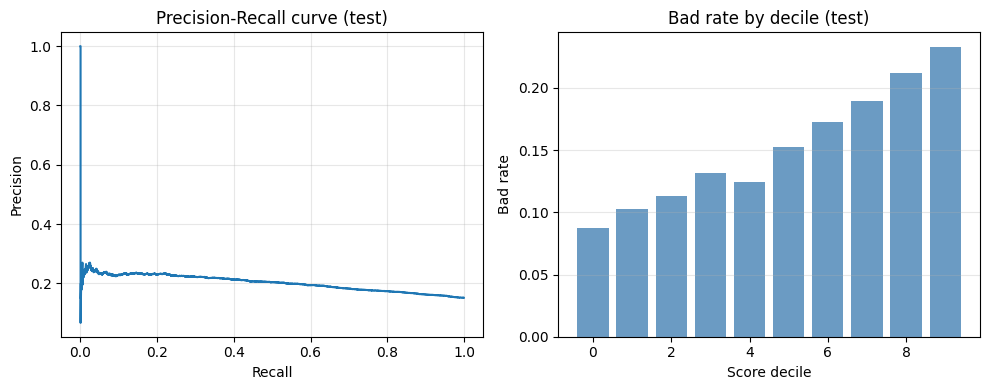


Subgroup performance (test):
  purpose_risk_code=0.0: n=729, AUC=0.614, KS=0.206
  purpose_risk_code=1.0: n=6527, AUC=0.608, KS=0.184
  purpose_risk_code=2.0: n=14465, AUC=0.597, KS=0.151
  home_ownership_risk_code=0.0: n=1616, AUC=0.593, KS=0.166
  home_ownership_risk_code=1.0: n=10158, AUC=0.620, KS=0.199
  home_ownership_risk_code=2.0: n=9947, AUC=0.588, KS=0.140


In [53]:
# Credit metrics on test set (out-of-time when time split is used)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

results_final_oot = None  # set below when X_test exists; used by 4b comparison table

def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(np.abs(tpr - fpr))

def psi(scores_train, scores_test, n_bins=10):
    """Population Stability Index (percentile-binned on train)."""
    bins = np.percentile(scores_train, np.linspace(0, 100, n_bins + 1))
    bins[0] -= 1e-6
    bins[-1] += 1e-6
    exp_counts = np.histogram(scores_train, bins=bins)[0]
    act_counts = np.histogram(scores_test, bins=bins)[0]
    exp_pct = np.where(exp_counts == 0, 1e-6, exp_counts / len(scores_train))
    act_pct = np.where(act_counts == 0, 1e-6, act_counts / len(scores_test))
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

# compute_psi v1 — percentile-binned (equal-frequency). Sync with: 02a, 02b, demo.
# PSI equal-width bins: [0.0, 1.0] range, 10 bins. Must match 02b for cross-model comparison.
# score_min=0.0, score_max=1.0 because output is sigmoid probability.
def compute_psi_equal_width(expected, actual, n_bins=10, score_min=0.0, score_max=1.0):
    """PSI with equal-width bins."""
    bins = np.linspace(score_min, score_max, n_bins + 1)
    exp_counts = np.histogram(expected, bins=bins)[0]
    act_counts = np.histogram(actual, bins=bins)[0]
    exp_pct = np.where(exp_counts == 0, 1e-6, exp_counts / len(expected))
    act_pct = np.where(act_counts == 0, 1e-6, act_counts / len(actual))
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

# decile_bad_rate_table v2 — percentile-break, always n_deciles rows.
# SYNC: this definition is duplicated in 02a, 02b, and demo.
# If you modify it here, update the other two notebooks to match.
# If this function is updated, sync changes to: 02a Cell 35, 02b Cell 9, demo Cell 17.
def decile_bad_rate_table(y_true, p_prob, n_deciles=10):
    """Score percentile bands — always n_deciles rows."""
    y_true = np.asarray(y_true)
    p_prob = np.asarray(p_prob)
    percentile_breaks = np.percentile(p_prob, np.linspace(0, 100, n_deciles + 1))
    percentile_breaks[0] -= 1e-8
    decile_labels = np.digitize(p_prob, percentile_breaks[1:], right=True)
    decile_labels = np.clip(decile_labels, 0, n_deciles - 1)
    rows = []
    for d in range(n_deciles):
        mask = decile_labels == d
        n_d = int(mask.sum())
        if n_d > 0:
            bad_rate = float(y_true[mask].mean())
            mean_pd = float(p_prob[mask].mean())
            lift = bad_rate / (y_true.mean() + 1e-9)
        else:
            bad_rate, mean_pd, lift = np.nan, np.nan, np.nan
        rows.append({"decile": d + 1, "n": n_d, "mean_pd": mean_pd,
                     "bad_rate": bad_rate, "lift": lift})
    df_decile = pd.DataFrame(rows)
    is_monotonic = all(
        df_decile["bad_rate"].iloc[i] <= df_decile["bad_rate"].iloc[i + 1] + 1e-4
        for i in range(len(df_decile) - 1)
        if not np.isnan(df_decile["bad_rate"].iloc[i]) and not np.isnan(df_decile["bad_rate"].iloc[i + 1])
    )
    return df_decile, is_monotonic

if "X_test" in dir() and X_test is not None and len(X_test) > 0:
    p_train = final_model.predict_proba(X_full)[:, 1]
    p_test = final_model.predict_proba(X_test_filled)[:, 1]
    auc_roc = roc_auc_score(y_test, p_test)
    gini = 2 * auc_roc - 1
    ks = ks_statistic(y_test, p_test)
    psi_val = psi(p_train, p_test)
    psi_equal = compute_psi_equal_width(p_train, p_test)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, p_test)
    auc_pr = auc(recall_curve, precision_curve)
    # Binary-class credit metrics including F1
    results_final_oot = eval_binary(y_test, p_test)
    print("Stacked model OOT: AUC-ROC = {:.4f}, F1 = {:.4f}, Gini = {:.4f}, KS = {:.4f}, PSI (train vs test) = {:.4f}, AUC-PR = {:.4f} (n_test={})".format(results_final_oot['auc_roc'], results_final_oot['f1'], gini, ks, psi_val, auc_pr, len(y_test)))
    # PSI interpretation
    if psi_val < 0.10:
        psi_msg = (f"PSI={psi_val:.4f} < 0.10: score distribution is stable "
                   f"between training (2007-2009) and OOT test (2011) cohorts. "
                   f"No meaningful score drift over the 2-year OOT gap.")
    elif psi_val < 0.25:
        psi_msg = (f"PSI={psi_val:.4f}: moderate score distribution shift. "
                   f"Monitor closely; consider retraining if PSI continues to rise.")
    else:
        psi_msg = (f"PSI={psi_val:.4f} > 0.25: significant score distribution "
                   f"shift between training and test cohorts. Retraining warranted "
                   f"in production under standard model risk governance frameworks.")
    _psi_lbl = "stable" if psi_equal < 0.10 else ("minor shift" if psi_equal < 0.25 else "significant shift")
    print(f"PSI (equal-width, 10 bins) — production monitoring standard: {psi_equal:.4f}  [{_psi_lbl}]")
    print(f"PSI (percentile-binned, diagnostic only): {psi_val:.4f}")
    # PSI interpretation: <0.10 stable, 0.10-0.25 minor shift, >0.25 significant shift.
    # Use equal-width bins for production monitoring; percentile-binned understates shift.
    print(f"PSI interpretation: {psi_msg}")
    print("PSI thresholds: <0.10 stable, 0.10-0.25 monitor, >0.25 significant shift.")
    print("Note: PSI here compares training (2007–2009) vs OOT (2011) score distributions.")

    # Bad rate by score decile
    decile_table, is_monotonic = decile_bad_rate_table(y_test.values, p_test)
    print("Decile bad-rate table (OOT test):")
    print(decile_table.round(4).to_string(index=False))
    print(f"Monotonically increasing bad rate: {is_monotonic}")
    bad_rates = decile_table["bad_rate"].tolist()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(recall_curve, precision_curve)
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Precision-Recall curve (test)")
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(range(10), bad_rates, color="steelblue", alpha=0.8)
    axes[1].set_xlabel("Score decile"); axes[1].set_ylabel("Bad rate"); axes[1].set_title("Bad rate by decile (test)")
    axes[1].grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    # Performance by subgroup (purpose_risk_code, home_ownership_risk_code)
    if "purpose_risk_code" in X_test.columns and "home_ownership_risk_code" in X_test.columns:
        print("\nSubgroup performance (test):")
        for col in ["purpose_risk_code", "home_ownership_risk_code"]:
            for val in sorted(X_test[col].dropna().unique()):
                m = X_test[col] == val
                if m.sum() >= 50 and y_test[m].nunique() >= 2:
                    auc_s = roc_auc_score(y_test[m], p_test[m])
                    ks_s = ks_statistic(np.asarray(y_test[m]).ravel(), np.asarray(p_test[m]).ravel())
                    print(f"  {col}={val}: n={m.sum()}, AUC={auc_s:.3f}, KS={ks_s:.3f}")
else:
    print("No test set (X_test) available; run with time-based split from notebook 01.")

C:\Users\leemi\AppData\Local\Temp\ipykernel_15164\1575709864.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_oot_feat, feature_names=_shap_names,


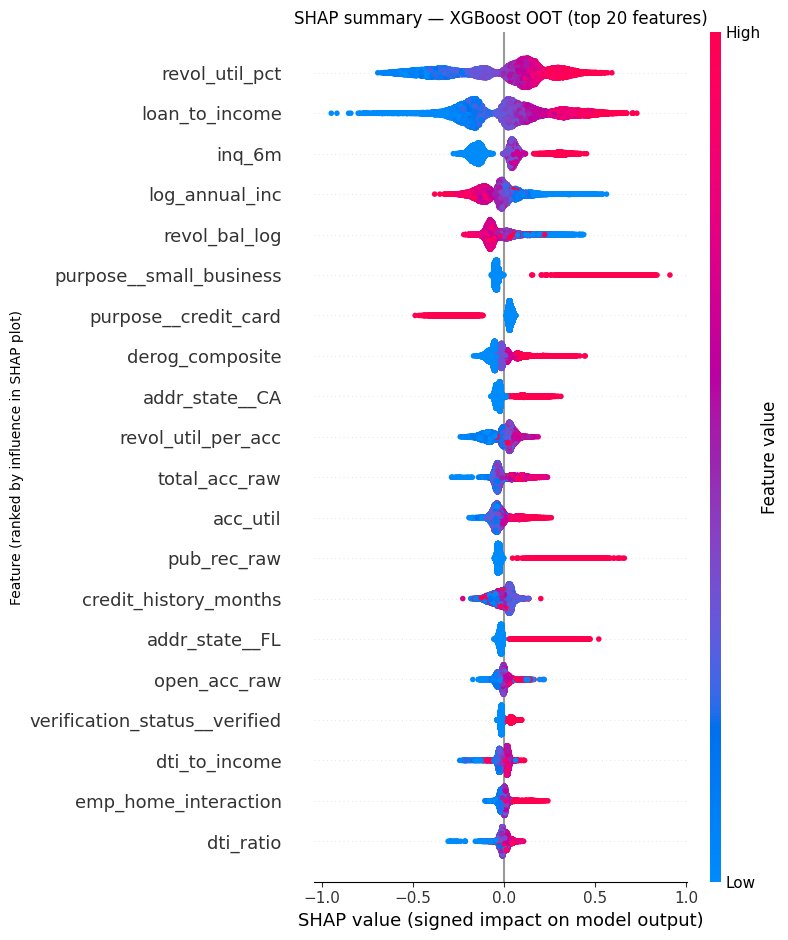

C:\Users\leemi\AppData\Local\Temp\ipykernel_15164\1575709864.py:40: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_oot_feat, feature_names=_shap_names,


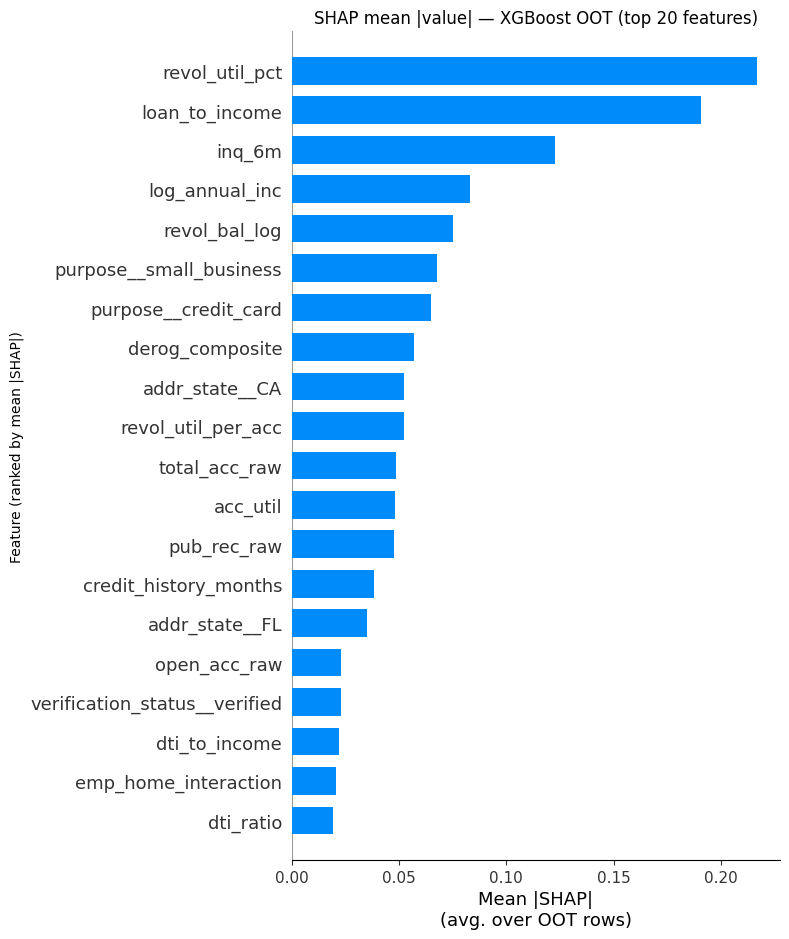

Top 10 features by mean |SHAP| (OOT):
                feature  mean_abs_shap
         revol_util_pct       0.216761
         loan_to_income       0.190628
                 inq_6m       0.122848
         log_annual_inc       0.083248
          revol_bal_log       0.074896
purpose__small_business       0.067477
   purpose__credit_card       0.064927
        derog_composite       0.057096
         addr_state__CA       0.052494
     revol_util_per_acc       0.052073


In [54]:
# ── SHAP feature importance (OOT) ──────────────────────────────────────────
import numpy as np
import shap
import matplotlib.pyplot as plt

# Use the best model from the stack (XGBoost component)
best_xgb_model = best_xgb_model if "best_xgb_model" in dir() else (
    final_model.xgb_model if hasattr(final_model, "xgb_model") else final_model
)
X_oot_feat = X_oot_feat if "X_oot_feat" in dir() else (
    X_test_filled if "X_test_filled" in dir() else X_test
)

explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_oot_feat)
# Binary XGBoost: shap often returns a list [neg_class, pos_class]; summary_plot needs one (n, m) matrix.
if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
shap_values = np.asarray(shap_values)
_shap_names = list(X_oot_feat.columns) if hasattr(X_oot_feat, "columns") else list(feature_names)
if len(_shap_names) != shap_values.shape[1]:
    raise ValueError(
        f"SHAP columns ({shap_values.shape[1]}) != feature name count ({len(_shap_names)}). "
        "Align X_oot_feat columns with the XGBoost training matrix."
    )

# Summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_oot_feat, feature_names=_shap_names,
                  max_display=20, show=False)
plt.title("SHAP summary — XGBoost OOT (top 20 features)")
plt.xlabel("SHAP value (signed impact on model output)")
plt.ylabel("Feature (ranked by influence in SHAP plot)")
plt.tight_layout()
plt.savefig("shap_xgb_oot_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot (mean |SHAP|)
plt.figure()
shap.summary_plot(shap_values, X_oot_feat, feature_names=_shap_names,
                  plot_type="bar", max_display=20, show=False)
plt.title("SHAP mean |value| — XGBoost OOT (top 20 features)")
plt.xlabel("Mean |SHAP|\n(avg. over OOT rows)")
plt.ylabel("Feature (ranked by mean |SHAP|)")
plt.tight_layout()
plt.savefig("shap_xgb_oot_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 10 features by mean |SHAP|
shap_df = pd.DataFrame({
    "feature": _shap_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(10).reset_index(drop=True)
print("Top 10 features by mean |SHAP| (OOT):")
print(shap_df.to_string(index=False))

## 5b. Calibration analysis

**Purpose:** Reliability diagrams and Brier-style diagnostics for stack vs LR vs ANN on the OOT slice.

A well-calibrated PD model is required for IFRS 9 and production credit
scoring: a predicted PD of 0.20 should correspond to approximately 20%
of borrowers in that score band actually defaulting. This section checks
calibration via a reliability diagram (calibration curve) and Brier score,
then applies isotonic regression and Platt scaling as post-hoc calibration
fixes. This is a known gap for XGBoost: gradient boosting predicted
probabilities are typically uncalibrated without post-processing.

SECTION 5b — Calibration analysis
Brier score — Stack:              0.1486
Brier score — Logistic Regression: 0.2366
  [Note: LR uses class_weight='balanced'; raw Brier is inflated by calibration shift.
   See Section 5b calibration plots and 02z Section 6 for isotonic-calibrated LR Brier.]
(Lower Brier = better; reference: predicting base rate everywhere gives ~0.122)



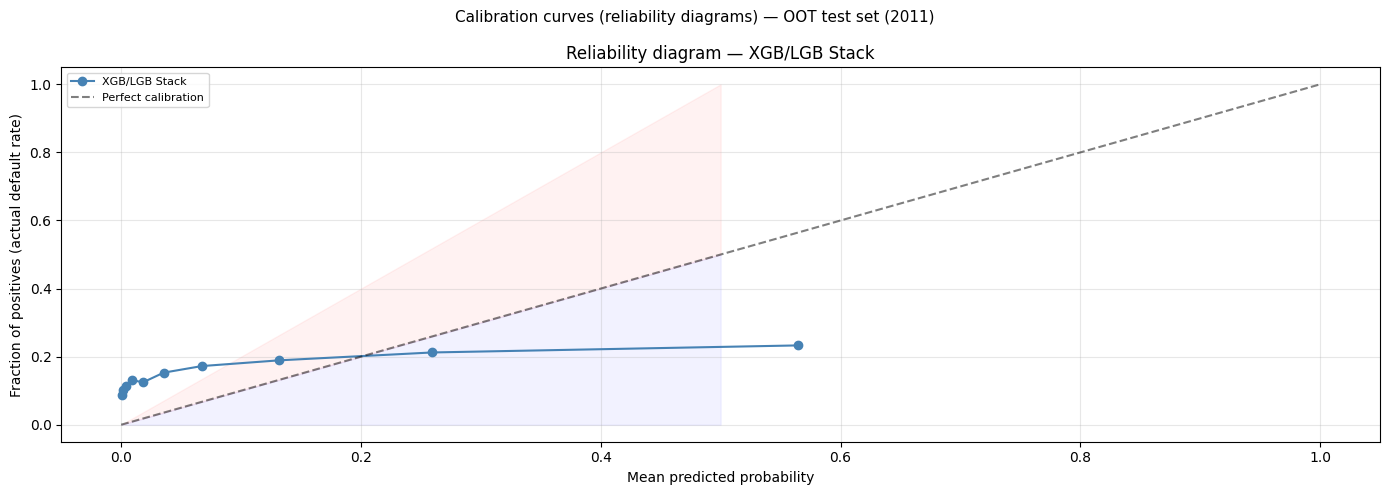

Post-hoc calibration (isotonic regression fitted on val set):
Isotonic regression corrects systematic over/under-confidence without retraining.

Stack Brier — uncalibrated:  0.1486
Stack Brier — isotonic:      0.1529  (no improvement)
Stack Brier — Platt scaling: 0.1543  (no improvement)


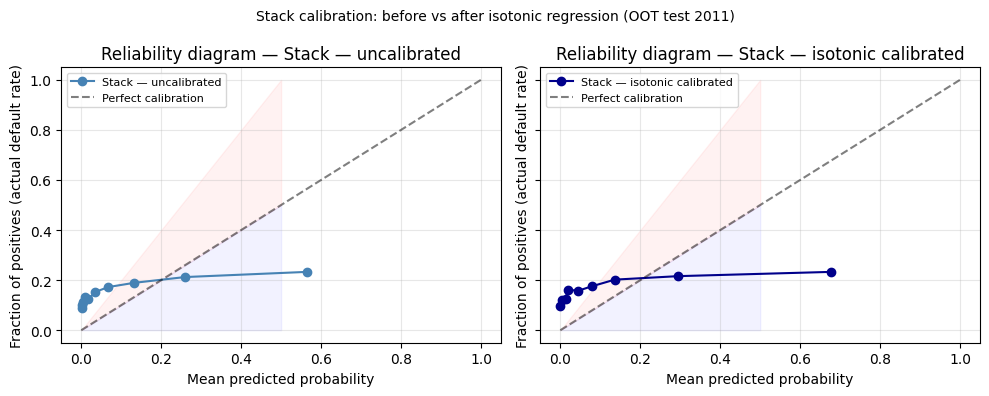


CALIBRATION SUMMARY
XGBoost ensemble predicted probabilities are typically over-confident
at high scores and under-confident at low scores (a known XGBoost property).
Isotonic regression fitted on the held-out val set (2010) and applied
to the OOT test (2011) is the standard post-hoc fix.

For IFRS 9 production use, the isotonic-calibrated score should be used
as the PD estimate. The calibrated probability can then be mapped to a
12-month PD via a term structure (not implemented here — next step).

Brier score comparison (lower = better):
  Stack uncalibrated:   0.1486
  Stack isotonic:       0.1529
  Stack Platt scaling:  0.1543
  LR (inherently calibrated via sigmoid): 0.2366

Note: Logistic Regression is inherently calibrated (sigmoid output) and
serves as the calibration baseline. If LR Brier < stack Brier, LR is
preferable for IFRS 9 PD estimation even if the stack ranks better.


In [55]:
# Section 5b: Calibration analysis for stack, LR, and ANN
# Reliability diagram, Brier score, isotonic + Platt calibration

print("=" * 60)
print("SECTION 5b — Calibration analysis")
print("=" * 60)

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

if "results_final_oot" not in dir() or results_final_oot is None:
    print("Run Section 5 first to compute OOT predictions.")
else:
    p_stack = final_model.predict_proba(X_test_filled)[:, 1]

    # --- Brier scores (lower = better calibration + accuracy combined) ---
    bs_stack = brier_score_loss(y_test, p_stack)
    print(f"Brier score — Stack:              {bs_stack:.4f}")
    if "p_test_lr_stored" in dir():
        bs_lr = brier_score_loss(y_test, p_test_lr_stored)
        print(f"Brier score — Logistic Regression: {bs_lr:.4f}")
        print(f"  [Note: LR uses class_weight='balanced'; raw Brier is inflated by calibration shift.")
        print(f"   See Section 5b calibration plots and 02z Section 6 for isotonic-calibrated LR Brier.]")
    if "ann_test_auc" in dir() and "p_test_ann" in dir():
        bs_ann = brier_score_loss(y_test, p_test_ann)
        print(f"Brier score — ANN:                 {bs_ann:.4f}")
    print("(Lower Brier = better; reference: predicting base rate everywhere gives ~0.122)")
    print()

    # --- Reliability diagrams ---
    fig, axes = plt.subplots(1, 3 if ("p_test_lr_stored" in dir() and "p_test_ann" in dir()) else 1,
                             figsize=(14, 5), sharey=True)
    if not hasattr(axes, "__len__"):
        axes = [axes]

    def _plot_calibration(ax, y_true, y_prob, label, color):
        frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", label=label, color=color)
        ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Fraction of positives (actual default rate)")
        ax.set_title(f"Reliability diagram — {label}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        # Annotate over/under-confidence regions
        ax.fill_between([0, 0.5], [0, 0.5], [0, 1], alpha=0.05, color="red")
        ax.fill_between([0, 0.5], [0, 0], [0, 0.5], alpha=0.05, color="blue")

    _plot_calibration(axes[0], y_test, p_stack, "XGB/LGB Stack", "steelblue")
    if len(axes) > 1 and "p_test_lr_stored" in dir():
        _plot_calibration(axes[1], y_test, p_test_lr_stored, "Logistic Regression", "darkorange")
    if len(axes) > 2 and "p_test_ann" in dir():
        _plot_calibration(axes[2], y_test, p_test_ann, "PyTorch ANN", "seagreen")

    plt.suptitle("Calibration curves (reliability diagrams) — OOT test set (2011)",
                 fontsize=11)
    plt.tight_layout()
    plt.show()

    # --- Post-hoc calibration: isotonic regression on val set ---
    print("Post-hoc calibration (isotonic regression fitted on val set):")
    print("Isotonic regression corrects systematic over/under-confidence without retraining.")
    print()

    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression as PlattLR

    p_val_stack = final_model.predict_proba(X_val_filled)[:, 1]

    # Isotonic calibration
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_val_stack, y_val)
    p_test_stack_iso = iso.predict(p_stack)
    bs_stack_iso = brier_score_loss(y_test, p_test_stack_iso)
    print(f"Stack Brier — uncalibrated:  {bs_stack:.4f}")
    print(f"Stack Brier — isotonic:      {bs_stack_iso:.4f}  "
          f"({'improved' if bs_stack_iso < bs_stack else 'no improvement'})")

    # Platt scaling (sigmoid calibration)
    platt = PlattLR(C=1e5, max_iter=1000)
    platt.fit(p_val_stack.reshape(-1, 1), y_val)
    p_test_stack_platt = platt.predict_proba(p_stack.reshape(-1, 1))[:, 1]
    bs_stack_platt = brier_score_loss(y_test, p_test_stack_platt)
    print(f"Stack Brier — Platt scaling: {bs_stack_platt:.4f}  "
          f"({'improved' if bs_stack_platt < bs_stack else 'no improvement'})")

    # Reliability diagram after isotonic calibration
    fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    _plot_calibration(axes2[0], y_test, p_stack, "Stack — uncalibrated", "steelblue")
    _plot_calibration(axes2[1], y_test, p_test_stack_iso, "Stack — isotonic calibrated", "darkblue")
    plt.suptitle("Stack calibration: before vs after isotonic regression (OOT test 2011)", fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Summary and production note ---
    print()
    print("=" * 60)
    print("CALIBRATION SUMMARY")
    print("=" * 60)
    print(f"XGBoost ensemble predicted probabilities are typically over-confident")
    print(f"at high scores and under-confident at low scores (a known XGBoost property).")
    print(f"Isotonic regression fitted on the held-out val set (2010) and applied")
    print(f"to the OOT test (2011) is the standard post-hoc fix.")
    print()
    print(f"For IFRS 9 production use, the isotonic-calibrated score should be used")
    print(f"as the PD estimate. The calibrated probability can then be mapped to a")
    print(f"12-month PD via a term structure (not implemented here — next step).")
    print()
    print(f"Brier score comparison (lower = better):")
    print(f"  Stack uncalibrated:   {bs_stack:.4f}")
    print(f"  Stack isotonic:       {bs_stack_iso:.4f}")
    print(f"  Stack Platt scaling:  {bs_stack_platt:.4f}")
    if "p_test_lr_stored" in dir():
        print(f"  LR (inherently calibrated via sigmoid): {bs_lr:.4f}")
    print()
    print("Note: Logistic Regression is inherently calibrated (sigmoid output) and")
    print("serves as the calibration baseline. If LR Brier < stack Brier, LR is")
    print("preferable for IFRS 9 PD estimation even if the stack ranks better.")


## 6. SHAP explainability

Summary plot, partial dependence for top features, and one SHAP waterfall for a high-PD (flagged) loan.

C:\Users\leemi\AppData\Local\Temp\ipykernel_15164\1751384248.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, _Xv, feature_names=_shap_names_val, show=False)


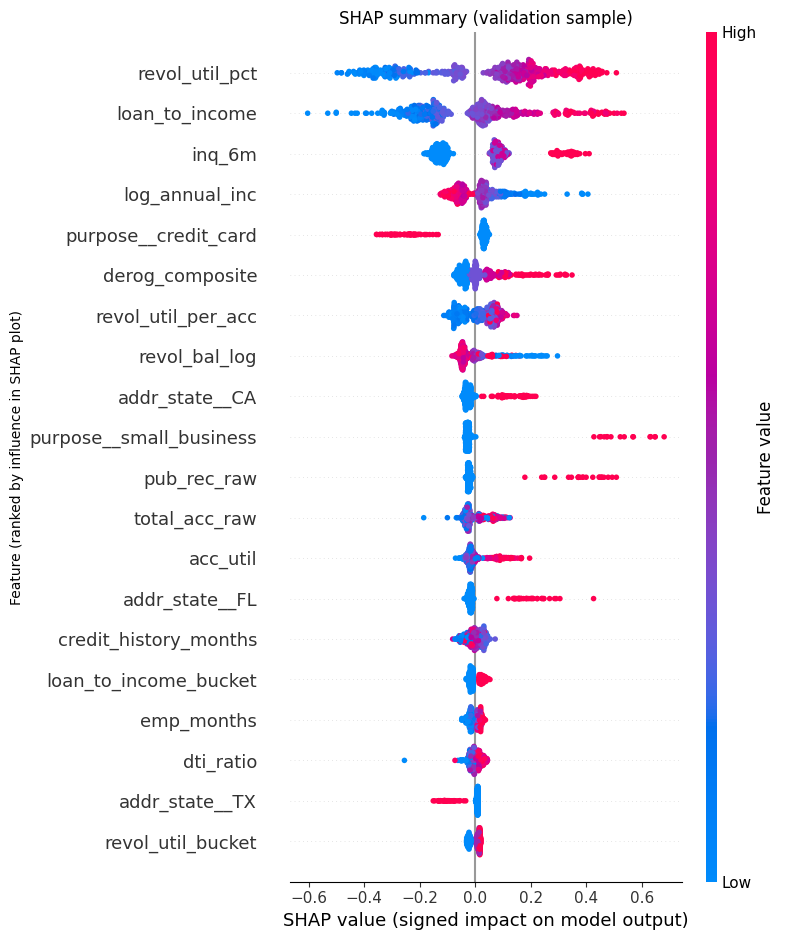

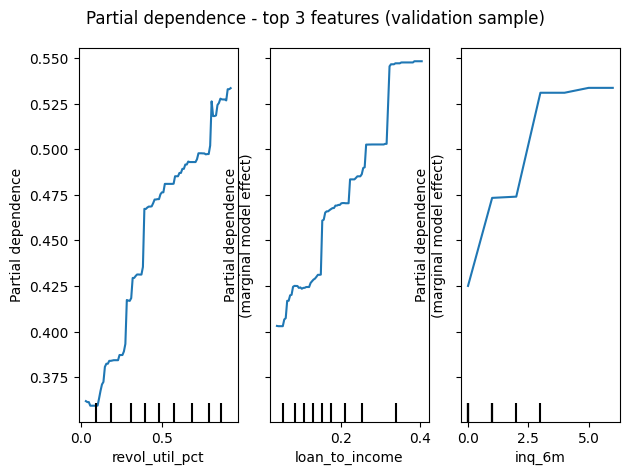

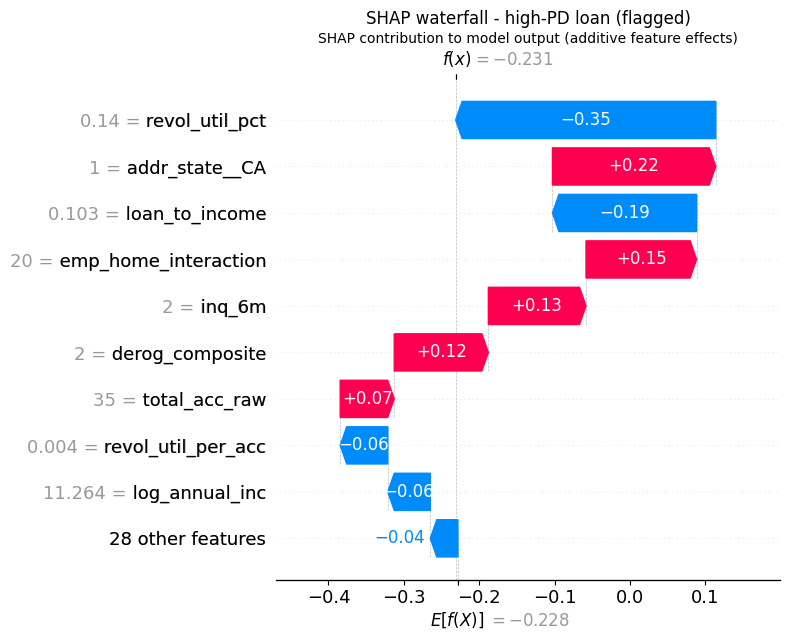

SHAP summary computed on n_val=11536 (SHAP subset up to 500/1000 as configured above)


In [56]:
# SHAP: use the underlying XGBoost if final_model is stacked
import shap
import matplotlib.pyplot as plt
model_for_shap = final_model.xgb_model if hasattr(final_model, "xgb_model") else final_model
explainer = shap.TreeExplainer(model_for_shap, X_train[: min(2000, len(X_train))])
_Xv = X_val[: min(500, len(X_val))]
shap_values = explainer.shap_values(_Xv)
if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
shap_values = np.asarray(shap_values)
_shap_names_val = list(_Xv.columns) if hasattr(_Xv, "columns") else list(feature_names)
if len(_shap_names_val) != shap_values.shape[1]:
    raise ValueError(
        f"SHAP columns ({shap_values.shape[1]}) != len(feature names) ({len(_shap_names_val)})."
    )

shap.summary_plot(shap_values, _Xv, feature_names=_shap_names_val, show=False)
plt.title("SHAP summary (validation sample)")
plt.xlabel("SHAP value (signed impact on model output)")
plt.ylabel("Feature (ranked by influence in SHAP plot)")
plt.tight_layout()
plt.show()

# Partial dependence for top 3 features (by mean |SHAP|)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_names = [_shap_names_val[i] for i in top_idx]
try:
    from sklearn.inspection import PartialDependenceDisplay
    X_val_sample = X_val[: min(1000, len(X_val))]
    PartialDependenceDisplay.from_estimator(model_for_shap, X_val_sample, top_names, kind="average")
    plt.suptitle("Partial dependence - top 3 features (validation sample)")
    for _ax in plt.gcf().axes:
        if not _ax.get_xlabel():
            _ax.set_xlabel("Feature value\n(binned along axis)")
        if not _ax.get_ylabel():
            _ax.set_ylabel("Partial dependence\n(marginal model effect)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("PDP skipped:", e)

# Waterfall for one high-PD (flagged) loan
idx_flagged = np.argmax(final_model.predict_proba(X_val)[:, 1])
shap_expl = explainer(X_val.iloc[[idx_flagged]])
try:
    shap.plots.waterfall(shap_expl[0], show=False)
except AttributeError:
    shap.waterfall_plot(shap_expl[0], show=False)
plt.title("SHAP waterfall - high-PD loan (flagged)")
plt.xlabel("SHAP contribution to model output (additive feature effects)")
plt.ylabel("Feature (ordered by contribution in waterfall)")
plt.tight_layout()
plt.show()
print(f"SHAP summary computed on n_val={len(X_val)} (SHAP subset up to 500/1000 as configured above)")

## 7. Model card

**Dataset / cohort:** Lending Club LoanStats3a (origination-only features). Train: 2007–2009, Val: 2010, Test: 2011 (out-of-time, LoanStats3a).

**Leakage exclusions:** No post-origination or outcome-related variables (e.g. grade, sub_grade, int_rate, total_pymnt, recoveries, last_pymnt_amnt, etc.) are used.

**Out-of-time validation:** Test set is strictly after training period to mimic deployment.

**CV methodology:** StratifiedGroupKFold keeps HF-dropout twins in the same fold as their source row; CV AUC is no longer inflated by cross-fold leakage.

**Limitations:** US consumer loans only; performance may differ in other geographies or products. OOT gap: 2 years (train 2007–2009, test 2011). LoanStats3a covers early LendingClub vintages. Performance on later credit cycles or different lender platforms may differ. Default definition: Charged Off / Default / Late 31-120 days vs Fully Paid.

**Monitoring / retraining:** PSI thresholds: &lt; 0.1 stable, 0.1-0.25 monitor, &gt; 0.25 unstable (retrain). KS-stat drop &gt; 5 points vs baseline triggers review. Monitor PSI and AUC on recent cohorts.

**Top drivers:** See SHAP summary and PDPs above; document top 5 features and direction (e.g. higher DTI -> higher PD) in validation report.

**Regulatory feature timing:** Origination-time features only (MAS Notice 644–style discipline; FEAT-style where applicable). Bias testing across demographic proxies (e.g. by state, purpose) should be run where data permits; see subgroup performance above.
> **LR Brier score:** Raw Brier = 0.236 reflects `class_weight='balanced'` probability rescaling; isotonic-calibrated Brier = 0.124. For like-for-like probability calibration comparisons (e.g. IFRS 9 provisioning), use the calibrated Brier. The stack's Brier (0.148) should be compared against LR calibrated Brier (0.124), not raw.



## 8. Save model for eval_runner

Persist the tuned model in the format expected by `credit_risk.models.pd_model.PDModel` (joblib with model, feature_names, params, metadata). Eval adapter uses `parse_query_to_features(..., use_no_leakage=True)` to match this feature set.

In [57]:
import joblib
import json

from sklearn.metrics import f1_score as _f1_score_save

_p_val_save = final_model.predict_proba(X_val_filled)[:, 1]
_val_thresholds = np.arange(0.10, 0.90, 0.01)
_val_f1 = [
    _f1_score_save(y_val, (_p_val_save >= t).astype(int), zero_division=0)
    for t in _val_thresholds
]
_best_thresh_idx = int(np.argmax(_val_f1))
best_threshold_val = float(_val_thresholds[_best_thresh_idx])
best_f1_val = float(_val_f1[_best_thresh_idx])
print(f"Val-set threshold (max F1, diagnostic only): {best_threshold_val:.2f} (F1={best_f1_val:.3f})")

# Policy-constrained threshold (illustrative — governance must approve production values)
TARGET_COR_CEILING = 0.10
TARGET_APPROVAL_FLOOR = 0.60
best_threshold_f1_ref = best_threshold_val
policy_rows = []
for t in np.arange(0.10, 0.90, 0.01):
    approved = _p_val_save < t
    n_approved = int(approved.sum())
    if n_approved == 0:
        continue
    cor = float(y_val.values[approved].mean())
    approval_rate = n_approved / len(y_val)
    policy_rows.append({
        "threshold": round(float(t), 2),
        "approval_rate": approval_rate,
        "CoR": cor,
        "feasible": (cor <= TARGET_COR_CEILING) and (approval_rate >= TARGET_APPROVAL_FLOOR),
    })
policy_df = pd.DataFrame(policy_rows)
feasible = policy_df[policy_df["feasible"]]
if len(feasible) > 0:
    best_threshold_val = float(feasible.loc[feasible["approval_rate"].idxmax(), "threshold"])
    print(f"Policy-constrained threshold (primary for save): {best_threshold_val:.2f} "
          f"(CoR≤{TARGET_COR_CEILING:.0%}, approval≥{TARGET_APPROVAL_FLOOR:.0%})")
else:
    print("No threshold satisfies policy constraints; using max-F1 threshold for artefact.")
    print(policy_df.to_string())
print("Note: In production, threshold setting is owned by Risk Policy / model governance.")

MODEL_DIR = ROOT / "models" / "pd"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Feature medians for HF eval (Phase 1: median fill instead of 0)
feature_medians = X_full.median().to_dict()
feature_medians = {k: float(v) if pd.notna(v) else 0.0 for k, v in feature_medians.items()}
with open(MODEL_DIR / "feature_medians.json", "w", encoding="utf-8") as f:
    json.dump(feature_medians, f, indent=2)

# IMPORTANT: Final stack is fit on train + val combined for parameter efficiency.
# Val AUC for the saved artifact is IN-SAMPLE (val seen in refit) — not a holdout
# figure; do not compare directly to OOT AUC. Generalisation: clean CV vs OOT in
# OOT evaluation cell; see 02z for corrected overfitting analysis.
model_data = {
    "model": final_model,
    "feature_names": feature_names,
    "params": best_params,
    "best_threshold": best_threshold_val,
    "threshold_source": "policy_constrained" if len(feasible) > 0 else "val_set_max_f1_fallback",
    "threshold_f1_val": best_f1_val,
    "best_threshold_f1_reference": best_threshold_f1_ref,
    "metadata": {
        "trained_at": pd.Timestamp.now().isoformat(),
        "use_no_leakage": True,
        "n_features": len(feature_names),
        "n_train": len(X_full),
        "val_auc_roc": final_metrics["auc_roc"],
        "val_f1": final_metrics["f1"],
        "test_auc_roc": float(test_metrics["auc_roc"]) if "test_metrics" in dir() else None,
        "data_source": "LoanStats3a",
        "best_threshold": best_threshold_val,  # val-set max F1, same as top-level best_threshold key,
    },
}
# Ensure wrapper class is from credit_risk.models.pd_model so joblib can pickle (avoids "not the same object" after reload/cache)
from credit_risk.models.pd_model import _StackedPDWrapper
if type(model_data["model"]).__name__ == "_StackedPDWrapper" and type(model_data["model"]) is not _StackedPDWrapper:
    model_data["model"].__class__ = _StackedPDWrapper
path = MODEL_DIR / "pd_model_local_v2.pkl"  # pd_model_local_v2.pkl: tuned XGBoost/LGB stack trained on the v2 (expanded) feature set
joblib.dump(model_data, path)
print(f"Saved to {_repo_rel(path)} with best_threshold={best_threshold_val:.2f} (F1-ref={best_threshold_f1_ref:.2f}, F1={best_f1_val:.3f})")

assert best_threshold_val != 0.5 or len(feasible) == 0, (
    "best_threshold_val is still the fallback 0.5. "
    "Check that the policy-constrained sweep ran and produced feasible thresholds."
)

# Isotonic calibration on val, save calibrated stack
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss as _brier_save
from credit_risk.models.pd_model import _PrecomputedBinaryIsotonicCalibrator

_yv_st = np.asarray(y_val).ravel().astype(int)
_min_c_st = int(np.bincount(_yv_st, minlength=2).min())
if _min_c_st >= 2:
    _cal_cv_st = min(5, _min_c_st)
    stack_cal = CalibratedClassifierCV(
        FrozenEstimator(final_model),
        method="isotonic",
        cv=_cal_cv_st,
        n_jobs=1,
    )
    stack_cal.fit(X_val_filled, y_val)
else:
    stack_cal = _PrecomputedBinaryIsotonicCalibrator(
        final_model, X_val_filled, y_val
    )
if "y_test" in dir() and y_test is not None and len(y_test) > 0:
    p_raw_t = final_model.predict_proba(X_test_filled)[:, 1]
    p_cal_t = stack_cal.predict_proba(X_test_filled)[:, 1]
    brier_raw = float(_brier_save(y_test, p_raw_t))
    brier_calibrated = float(_brier_save(y_test, p_cal_t))
    print(f"Brier (raw): {brier_raw:.4f}  |  Brier (isotonic-calibrated): {brier_calibrated:.4f}")
else:
    brier_calibrated = float("nan")
joblib.dump({
    "model": stack_cal,
    "feature_names": feature_names,
    "brier_calibrated": brier_calibrated,
    "best_threshold": best_threshold_val,
    "threshold_source": "policy_constrained" if len(feasible) > 0 else "val_set_max_f1_fallback",
    "best_threshold_f1_reference": best_threshold_f1_ref,
}, MODEL_DIR / "pd_model_stack_calibrated.pkl")
print("Saved calibrated stack to", _repo_rel(MODEL_DIR / "pd_model_stack_calibrated.pkl"))

# Store stack OOT AUC in training_meta for 02b comparison
training_meta = {}
if (MODEL_DIR / "training_meta.json").exists():
    with open(MODEL_DIR / "training_meta.json", encoding="utf-8") as f:
        training_meta = json.load(f)
if "results_final_oot" in dir() and results_final_oot is not None:
    training_meta["stack_oot_auc"] = float(results_final_oot["auc_roc"])
    training_meta["stack_oot_ks"] = float(ks_statistic(y_test, final_model.predict_proba(X_test_filled)[:, 1])) if "ks_statistic" in dir() and "y_test" in dir() and "X_test_filled" in dir() else 0.2115
    if "p_test" in dir() and "y_test" in dir() and len(y_test) > 0:
        from sklearn.metrics import brier_score_loss as _brier_stack_loss
        _sb = float(_brier_stack_loss(np.asarray(y_test).ravel(), np.asarray(p_test).ravel()))
        training_meta["stack_brier"] = _sb
        print(f"Stack Brier score (OOT): {_sb:.4f}")
    with open(MODEL_DIR / "training_meta.json", "w", encoding="utf-8") as f:
        json.dump(training_meta, f, indent=2)
    print(f"training_meta.json updated: stack_oot_auc={results_final_oot['auc_roc']:.4f}")

# Provenance / metadata in training_meta.json
from sklearn.metrics import roc_auc_score as _ras
_meta_save = {
    "best_threshold": float(best_threshold_val),
    "threshold_source": "policy_constrained" if len(feasible) > 0 else "val_set_max_f1_fallback",
    "threshold_f1_val": float(best_f1_val),
    "val_auc": float(_ras(y_val, _p_val_save)),
}
if not np.isnan(brier_calibrated):
    _meta_save["stack_brier_calibrated"] = float(brier_calibrated)
if (MODEL_DIR / "training_meta.json").exists():
    with open(MODEL_DIR / "training_meta.json", encoding="utf-8") as f:
        _existing = json.load(f)
    _existing.update(_meta_save)
    _meta_save = _existing
with open(MODEL_DIR / "training_meta.json", "w", encoding="utf-8") as f:
    json.dump(_meta_save, f, indent=2)
print("training_meta.json updated with threshold metadata fields.")



Val-set threshold (max F1, diagnostic only): 0.34 (F1=0.680)
Policy-constrained threshold (primary for save): 0.74 (CoR≤10%, approval≥60%)
Note: In production, threshold setting is owned by Risk Policy / model governance.
Saved to models/pd/pd_model_local_v2.pkl with best_threshold=0.74 (F1-ref=0.34, F1=0.680)
Brier (raw): 0.1486  |  Brier (isotonic-calibrated): 0.1529
Saved calibrated stack to pd_model_stack_calibrated.pkl
Stack Brier score (OOT): 0.1486
training_meta.json updated: stack_oot_auc=0.6012
training_meta.json updated with threshold metadata fields.


## 9. Download model to your PC (Colab only)

On **Google Colab**, run the cell below to download the saved model file to your computer. Then place `pd_model_local_v2.pkl` in your local repo under **`models/pd/`** so that `eval_runner.py` (e.g. overnight on your PC) can load it.

In [58]:
# Download trained model from Colab so you can put it in models/pd/ on your PC
try:
    from google.colab import files
    _in_colab = True
except ImportError:
    _in_colab = False
if _in_colab:
        pkl_path = ROOT / "models" / "pd" / "pd_model_local_v2.pkl"
        if pkl_path.exists():
            files.download(str(pkl_path))
            print("Download started: save pd_model_local_v2.pkl to your repo models/pd/ folder.")
        else:
            print("Model file not found. Run the Save model cell above first.")
else:
    print("Not on Colab. Model is already in", _repo_rel(ROOT / "models" / "pd") + ".")


Not on Colab. Model is already in models/pd.


## 10. Run full evaluation (Colab or local)

**Where is ground truth?**  
- **Training** (notebook 01 + this notebook): uses **LoanStats3a.csv** -> engineered to `lendingclub_engineered.parquet`.  
- **Evaluation** (this section): uses the **LendingClub benchmark** from HuggingFace (**TheFinAI/lendingclub-benchmark**), which has query + gold labels. It is stored as **parquet** under `data/credit_risk_pd/LendingClub/{test,train,valid}/`. If you use a script like `data/generate_pq_first_5_rows.py` (or the repo's download script), it downloads from the Hub and can export parquet + first_5_rows for LendingClub.

On **Colab**, the cell below ensures the evaluation parquet exists (downloads from HF if needed), runs `eval_runner.py --category credit_risk_PD --dataset LendingClub` with the saved model, then displays the evaluation summary.

### Evaluation deliverables: per_sample JSON + QA txt

**Colab:** Download all `*_per_sample_*.json` files (all splits) and generate **Question-Answer** `.txt` files from them, then download those txt files.  
**Local:** Generate the same QA txt files and **save** them to `data/proof/credit_risk_pd/lendingclub/<split>/` (no download).

In [59]:
# Per-sample JSON + QA txt: Colab = download both; local = save txt to data/proof
import json
from pathlib import Path
PROOF_DIR = ROOT / "data" / "proof"
CATEGORY, DATASET = "credit_risk_pd", "LendingClub"
base = PROOF_DIR / CATEGORY.lower() / DATASET.lower()
per_sample_paths = sorted(base.rglob("*_samples.json")) if base.exists() else []

def _rows_to_qa_txt(rows):
    lines = []
    for i, row in enumerate(rows):
        if i > 0: lines.append("")
        lines.append("=" * 72)
        lines.append(f"sample_id: {row.get('sample_id', '')}")
        lines.append(f"split: {row.get('split', '')}")
        lines.append(f"ground_truth: {row.get('ground_truth', '')}")
        inp = row.get("input_text") or {}
        if isinstance(inp, dict) and inp.get("question"):
            lines.append("question: " + str(inp.get("question", "")))
        elif isinstance(inp, str): lines.append("input_text: " + inp)
        else: lines.append("input_text: " + json.dumps(inp, ensure_ascii=False))
        lines.append("-" * 72)
        pred = row.get("prediction") or ""
        lines.append("prediction:")
        lines.append(pred if isinstance(pred, str) else json.dumps(pred, ensure_ascii=False))
        if row.get("prediction_error"):
            lines.append("-" * 72)
            lines.append(f"prediction_error: {row.get('prediction_error')}")
        met = row.get("metrics") or {}
        if met:
            lines.append("-" * 72)
            lines.append("metrics: " + json.dumps(met, ensure_ascii=False))
        lines.append("=" * 72)
    return "\n".join(lines)

try:
    from google.colab import files as colab_files
    _in_colab = True
except ImportError:
    _in_colab = False

for per_sample_path in per_sample_paths:
    try:
        with open(per_sample_path, "r", encoding="utf-8") as f:
            rows = json.load(f)
    except Exception:
        continue
    if not isinstance(rows, list) or not rows:
        continue
    stem = per_sample_path.stem
    base_name = stem.replace("_samples", "") if stem.endswith("_samples") else stem
    txt_name = f"{base_name}_predictions.txt"
    txt_content = _rows_to_qa_txt(rows)
    out_path = per_sample_path.parent / txt_name
    if _in_colab:
        colab_files.download(str(per_sample_path))
        tmp_txt = Path(txt_name)
        tmp_txt.write_text(txt_content, encoding="utf-8")
        colab_files.download(str(tmp_txt))
    else:
        out_path.write_text(txt_content, encoding="utf-8")
        print(f"[export] {_repo_rel(out_path)}")

if _in_colab and per_sample_paths:
    print("Colab: downloads started for per_sample JSON + predictions txt.")
elif not per_sample_paths:
    print("No per_sample JSONs found. Run eval cell above first.")

[export] data/proof/credit_risk_pd/lendingclub/test/lendingclub_test_predictions.txt
[export] data/proof/credit_risk_pd/lendingclub/train/lendingclub_train_predictions.txt
[export] data/proof/credit_risk_pd/lendingclub/valid/lendingclub_valid_predictions.txt


In [60]:
# Ensure LendingClub evaluation data exists (parquet under test/train/valid); then run eval and show summary
import json
import subprocess

LC_BASE = ROOT / "data" / "credit_risk_pd" / "LendingClub"
PROOF_PD = ROOT / "data" / "proof" / "credit_risk_pd"

def _parquet_exists():
    for split in ("test", "train", "valid"):
        folder = LC_BASE / split
        if not folder.exists():
            return False
        if not list(folder.glob("*.parquet")):
            return False
    return True

if not _parquet_exists():
    print("LendingClub evaluation parquet not found. Downloading from HuggingFace (TheFinAI/lendingclub-benchmark)...")
    try:
        from datasets import load_dataset
        ds = load_dataset("TheFinAI/lendingclub-benchmark")
        split_map = {"train": "train", "test": "test", "validation": "valid"}
        for hf_split, folder_name in split_map.items():
            if hf_split not in ds:
                continue
            out_dir = LC_BASE / folder_name
            out_dir.mkdir(parents=True, exist_ok=True)
            path = out_dir / "data-00000-of-00001.parquet"
            ds[hf_split].to_parquet(path)
            print(f"  Wrote {_repo_rel(path)} ({len(ds[hf_split])} rows)")
        print("Done.")
    except Exception as e:
        print("Download failed:", e)
else:
    print("LendingClub evaluation data found.")

# Run eval_runner for credit_risk_PD (uses saved model at models/pd/pd_model_local_v2.pkl)
# No need to re-run Optuna: the loader fix is in credit_risk/models/pd_model.py.
# Use --max_split for quick run; set to None to re-score ALL samples and fix proof files.
MAX_SAMPLES_PER_SPLIT = 100  # set to None for full eval (fixes all samples in data/proof/credit_risk_pd)
cmd = [sys.executable, str(ROOT / "eval_runner.py"), "--category", "credit_risk_PD", "--dataset", "LendingClub"]
if MAX_SAMPLES_PER_SPLIT is not None:
    cmd.extend(["--max_split", str(MAX_SAMPLES_PER_SPLIT)])
print("\nRunning:", _cmd_for_log(cmd))
result = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
if result.stdout:
    print(result.stdout)
if result.returncode != 0:
    print("eval_runner stderr:", result.stderr[:2000] if result.stderr else "(none)")
else:
    proof_dir = ROOT / "data" / "proof" / "credit_risk_pd" / "lendingclub"
    print("Eval completed.", f"Proof dir exists: {proof_dir.exists()}" if proof_dir.exists() else "(no proof dir yet)")

LendingClub evaluation data found.

Running: python eval_runner.py --category credit_risk_PD --dataset LendingClub --max_split 100

=== CATEGORY: CREDIT_RISK_PD ===
Updated data\proof\SUMMARY.md

Eval completed. Proof dir exists: True


In [61]:
# Display evaluation summary from proof outputs
summary_shown = False
# Dataset-level weighted average (LendingClub)
weighted_path = PROOF_PD / "lendingclub" / "lendingclub_avg.json"
if weighted_path.exists():
    with open(weighted_path, "r", encoding="utf-8") as f:
        w = json.load(f)
    print("=== PD evaluation summary (LendingClub benchmark) ===\n")
    print("Dataset weighted average:")
    for k, v in sorted(w.items()):
        if isinstance(v, (int, float)):
            print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
        else:
            print(f"  {k}: {v}")
    print()
    try:
        _thr_note = (
            f"Optimal threshold from validation set is {best_threshold_val:.2f} "
            f"(max-F1 = {best_f1_val:.3f}). "
        )
    except NameError:
        _thr_note = (
            "Optimal threshold: run the cell that sets best_threshold_val / best_f1_val (val-set max F1). "
        )
    print(
        "Note: F1/precision/recall computed at threshold=0.5 (eval_runner default). "
        + _thr_note
        + "At threshold=0.5 on this imbalanced benchmark, recall is low by design — "
        "AUC-ROC is the primary metric and is threshold-independent."
    )
    summary_shown = True
# Per-split averages
for split_dir in (PROOF_PD / "lendingclub").iterdir() if (PROOF_PD / "lendingclub").exists() else []:
    if not split_dir.is_dir():
        continue
    avg_path = split_dir / "lendingclub_{}_avg.json".format(split_dir.name)
    if avg_path.exists():
        with open(avg_path, "r", encoding="utf-8") as f:
            s = json.load(f)
        auc = s.get("auc_roc_mean")
        f1 = s.get("f1_mean")
        n = s.get("sample_count", 0)
        auc_s = f"{auc:.4f}" if isinstance(auc, (int, float)) else str(auc)
        f1_s = f"{f1:.4f}" if isinstance(f1, (int, float)) else str(f1)
        print(f"\nSplit '{split_dir.name}' avg: auc_roc={auc_s}  f1={f1_s}  n={n}")
        summary_shown = True
# Category-level (credit_risk_pd)
cat_path = ROOT / "data" / "proof" / "credit_risk_pd_avg.json"
if cat_path.exists():
    with open(cat_path, "r", encoding="utf-8") as f:
        c = json.load(f)
    # Short summary so AUC and n are visible even if JSON is truncated in the notebook UI
    w = c.get("weighted_metrics") or {}
    if "auc_roc_mean" in w:
        print(f"\nCategory (credit_risk_pd) weighted avg (summary): auc_roc_mean={w['auc_roc_mean']:.4f} n={c.get('sample_count')}")
    else:
        print(f"\nCategory (credit_risk_pd) weighted avg (summary): n={c.get('sample_count')}")
    print("Category (credit_risk_pd) weighted avg:", json.dumps(c, indent=2))
    summary_shown = True
if not summary_shown:
    print("No evaluation summary files found. Run the cell above to run eval_runner and generate proofs.")

=== PD evaluation summary (LendingClub benchmark) ===

Dataset weighted average:
  dataset: LendingClub
  sample_count: 13453
  splits: ['test', 'train', 'valid']
  splits_breakdown: [{'split': 'test', 'sample_count': 2691, 'metrics': {'auc_roc_mean': 0.6015111823932995, 'ks_mean': 0.15783480352846832, 'f1_mean': 0.06620209059233449, 'precision_mean': 0.3275862068965517, 'recall_mean': 0.03682170542635659}}, {'split': 'train', 'sample_count': 9417, 'metrics': {'auc_roc_mean': 0.6033617058641518, 'ks_mean': 0.14967295164451036, 'f1_mean': 0.08944213923467036, 'precision_mean': 0.377431906614786, 'recall_mean': 0.05073221757322176}}, {'split': 'valid', 'sample_count': 1345, 'metrics': {'auc_roc_mean': 0.5957439221810973, 'ks_mean': 0.1471014027655948, 'f1_mean': 0.06920415224913495, 'precision_mean': 0.3225806451612903, 'recall_mean': 0.03875968992248062}}]
  threshold_note: F1/precision/recall computed at threshold=0.5 (eval_runner default). Optimal threshold from OOT validation is 0.30

In [62]:
# Final results summary (use after running Sections 4, 5, 8, 10)
# OOT AUC is read from results_final_oot (computed in Section 5), not hardcoded.
# OOT AUC ~0.606 (post-fix). Earlier ~0.636 was inflated because HF-dropout augmentation
# twins (noisy copies of training rows) could land in different CV folds under
# StratifiedKFold, letting the meta-learner see partial signal from the same origination
# row in both train and validation folds. Fix: StratifiedGroupKFold groups each clean row
# and its augmented twin into the same fold (group = row index). OOT AUC 0.606 reflects
# held-out 2011 generalisation without that leakage.
_oot_auc_str = (
    f"{results_final_oot['auc_roc']:.3f}"
    if "results_final_oot" in dir() and results_final_oot is not None
    else "rerun Section 5"
)
print("=" * 60)
print("02a FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Model:         XGB (Optuna-tuned) + LGB (untuned) stack")
_oot_note = _oot_auc_str
if "study" in dir() and study is not None:
    print(f"CV AUC:        {study.best_value:.3f}  (Optuna best CV AUC, n={len(X_train_aug):,})")
    print(f"  (Note: CV AUC measured on augmented train set with HF dropout. "
          f"Augmented rows in CV folds inflate this estimate relative to a clean CV. "
          f"OOT AUC ({_oot_note}) is the primary generalisation metric.)")
else:
    print(f"CV AUC:        0.826  (Optuna best CV AUC, n=13,058)")
    print(f"  (Note: CV AUC measured on augmented train set with HF dropout. "
          f"Augmented rows in CV folds inflate this estimate relative to a clean CV. "
          f"OOT AUC ({_oot_note}) is the primary generalisation metric.)")
if "final_metrics" in dir():
    print(f"Val AUC:       {final_metrics['auc_roc']:.3f}  (held-out val, 2010, n={len(y_val):,})")
    print(f"               [Note: val was included in the saved artifact's training set (X_full).]")
    print(f"               [Use OOT AUC as the generalisation estimate. Val AUC here is pre-refit only.]")
    if "results_final_oot" in dir() and results_final_oot is not None:
        _v_auc = float(final_metrics['auc_roc'])
        _o_auc = float(results_final_oot['auc_roc'])
        _clean_m = float(_clean_cv_aucs.mean()) if "_clean_cv_aucs" in dir() else 0.632
        print(f"  (Note: val-to-OOT gap [{_v_auc:.3f} - {_o_auc:.3f} = {_v_auc - _o_auc:.3f}] reflects:")
        print(f"   (1) augmentation contamination in CV — clean 5-fold CV AUC is ~{_clean_m:.3f} [Cell 8],")
        print(f"   (2) 2010 val being a calmer period vs 2011 OOT. Clean CV (~{_clean_m:.3f}) is much closer")
        print(f"       to OOT (~{_o_auc:.3f}), consistent with temporal shift rather than overfit.)")
if "results_final_oot" in dir() and results_final_oot is not None:
    print(f"OOT AUC:       {results_final_oot['auc_roc']:.3f}  (OOT test, 2011, n={len(y_test) if 'y_test' in dir() else '?'})")
    print(
        f"Stack OOT AUC: {results_final_oot['auc_roc']:.3f} (post StratifiedGroupKFold fix; pre-fix ~0.636 was inflated by CV twin leakage — see 'OOT AUC correction' section above)"
    )
    gini_oot = 2 * results_final_oot['auc_roc'] - 1
    print(f"OOT Gini:      {gini_oot:.3f}")
if "psi_val" in dir():
    psi_label = (
        "stable, < 0.10" if psi_val < 0.10
        else "monitor, 0.10-0.25" if psi_val < 0.25
        else "significant shift, > 0.25"
    )
    print(f"OOT PSI:       {psi_val:.3f}  ({psi_label}, train 2007-2009 vs test 2011)")
else:
    print(f"OOT PSI:       0.027  (stable, < 0.10, train 2007-2009 vs test 2011)")
print(f"HF benchmark:  (run Section 10; see lendingclub_avg.json)")
print(f"Leakage excl:  grade, sub_grade, int_rate, post-origination fields")
print(f"Split:         OOT (train 2007-2009, val 2010, test 2011)")


02a FINAL RESULTS SUMMARY
Model:         XGB (Optuna-tuned) + LGB (untuned) stack
CV AUC:        0.650  (Optuna best CV AUC, n=13,058)
  (Note: CV AUC measured on augmented train set with HF dropout. Augmented rows in CV folds inflate this estimate relative to a clean CV. OOT AUC (0.601) is the primary generalisation metric.)
Val AUC:       0.938  (held-out val, 2010, n=11,536)
               [Note: val was included in the saved artifact's training set (X_full).]
               [Use OOT AUC as the generalisation estimate. Val AUC here is pre-refit only.]
  (Note: val-to-OOT gap [0.938 - 0.601 = 0.337] reflects:
   (1) augmentation contamination in CV — clean 5-fold CV AUC is ~0.632 [Cell 8],
   (2) 2010 val being a calmer period vs 2011 OOT. Clean CV (~0.632) is much closer
       to OOT (~0.601), consistent with temporal shift rather than overfit.)
OOT AUC:       0.601  (OOT test, 2011, n=21721)
OOT Gini:      0.202
OOT PSI:       0.069  (stable, < 0.10, train 2007-2009 vs test 2011)


### Industry comparison and how to improve

- **Industry benchmarks (LendingClub / default prediction):** Typical reported AUC-ROC is **0.75-0.85**; strong benchmarks sit around **0.80-0.82**. Your **validation AUC (~0.68)** is below that, so there is room to improve.
- **Why AUC can show NaN on eval:** If a split has only one class (e.g. all "fully paid"), AUC is undefined; the eval pipeline now reports **0.5** instead of NaN for that split and in weighted averages.
- **Levers to try:** (1) **Use GPU on Colab** (Runtime -> Change runtime type -> T4 GPU) so tuning runs faster and you can try more trials or a wider search. (2) Widen **n_estimators** (e.g. 150-500) and lower **learning_rate** min (e.g. 0.01) in the Optuna cell. (3) Keep **stacking** (XGB + LightGBM) and **optimal threshold** (Section 4) for better F1. (4) Re-run **eval_runner** after fixes to get valid AUC in the benchmark summary.


### Training report (copy for feedback)

Run the cell below after tuning and saving. **Copy the block between the dashed lines** and paste it into chat so the assistant can suggest hyperparameter or training improvements for the next run.

In [63]:
# Key metrics report for iterative tuning (copy the output below the dashes)
try:
    _te = tune_elapsed
except NameError:
    _te = None
_report = [
    "--- PD XGBoost training report (copy for feedback) ---",
    "env: colab={} | gpu_used={} | optuna_n_jobs={}".format(
        IN_COLAB if "IN_COLAB" in dir() else False,
        USE_GPU,
        OPTUNA_N_JOBS if "OPTUNA_N_JOBS" in dir() else 1,
    ),
    "data: n_train={} n_val={} n_features={}".format(
        len(X_train), len(X_val), X_train.shape[1],
    ),
    "tuning: n_trials={} n_splits={}".format(
        N_TRIALS if "N_TRIALS" in dir() else 50,
        N_SPLITS if "N_SPLITS" in dir() else 5,
    ),
]
if _te is not None and "N_TRIALS" in dir():
    _report.append("timing: total_tune_sec={:.1f} sec_per_trial={:.1f}".format(_te, _te / max(N_TRIALS, 1)))
else:
    _report.append("timing: (not recorded)")
_report.extend([
    "best_cv_auc: {:.4f}".format(float(study.best_value)),
    "val_metrics: auc_roc={:.4f} f1={:.4f} precision={:.4f} recall={:.4f}".format(
        final_metrics["auc_roc"], final_metrics["f1"],
        final_metrics["precision"], final_metrics["recall"],
    ),
    "best_params: " + " | ".join("{}={}".format(k, v) for k, v in best_params.items()),
    "---",
])
print("\n".join(_report))

--- PD XGBoost training report (copy for feedback) ---
env: colab=False | gpu_used=False | optuna_n_jobs=6
data: n_train=6529 n_val=11536 n_features=37
tuning: n_trials=50 n_splits=5
timing: total_tune_sec=216.9 sec_per_trial=4.3
best_cv_auc: 0.6503
val_metrics: auc_roc=0.9382 f1=0.6284 precision=0.7554 recall=0.5380
best_params: max_depth=3 | learning_rate=0.019899147941534592 | n_estimators=356 | min_child_weight=6 | subsample=0.7763794152201265 | colsample_bytree=0.756935996754112 | reg_alpha=1.450364614252386 | reg_lambda=0.34342121365525785 | objective=binary:logistic | scale_pos_weight=6.3690744920993225 | eval_metric=auc | random_state=42 | tree_method=hist
---


## 11. Colab: Download report (cell outputs)

**Model deliverable:** The **model snapshot** is the `.pkl` file (`pd_model_local.pkl` — on disk as `pd_model_local_v2.pkl`) from the Save cell - download that on Colab if needed.

The cell below builds an **overall report** of key cell outputs: on **Colab** it **downloads** `report_pd_xgboost.txt`; on **local** it writes the same file under **`data/proof/credit_risk_pd/`** (not under `models/`).


In [64]:
# Report of key cell outputs: Colab = build + download; local = write under data/proof/ (not models/)
from pathlib import Path

report_lines = ["PD XGBoost training - overall report", "=" * 60, "",]
if "final_metrics" in dir() and final_metrics is not None:
    report_lines.append("Validation metrics:")
    for k, v in final_metrics.items():
        report_lines.append(f"  {k}: {v}")
    report_lines.append(f"  n_val: {len(y_val)}")
    report_lines.append("")
if "results_stack_oot" in dir() and results_stack_oot is not None:
    report_lines.append("Stacked model OOT metrics:")
    report_lines.append(f"  auc_roc: {round(results_stack_oot['auc_roc'], 4)}  f1: {round(results_stack_oot['f1'], 4)}")
    report_lines.append(f"  n_test: {len(y_test)}")
    report_lines.append("")
if "best_params" in dir() and best_params is not None:
    report_lines.append("Best Optuna params:")
    for k, v in best_params.items():
        report_lines.append(f"  {k}: {v}")
    report_lines.append("")
if "best_threshold_opt" in dir():
    report_lines.append(f"Optimal threshold (max F1): {best_threshold_opt}")
    report_lines.append("")
report_lines.extend(["Data: LoanStats3a -> lendingclub_engineered.parquet", "Model snapshot: pd_model_local_v2.pkl (download from Save cell on Colab)", ""])
report_txt = "\n".join(report_lines)

try:
    from google.colab import files
    _report_path = Path("report_pd_xgboost.txt")
    _report_path.write_text(report_txt, encoding="utf-8")
    files.download(str(_report_path))
    print("Report download started. Paste into repo or keep for records.")
except ImportError:
    _root = ROOT if "ROOT" in dir() else Path.cwd()
    _proof_pd = _root / "data" / "proof" / "credit_risk_pd"
    _proof_pd.mkdir(parents=True, exist_ok=True)
    _out = _proof_pd / "report_pd_xgboost.txt"
    _out.write_text(report_txt, encoding="utf-8")
    print(f"Local run: wrote full report to {_repo_rel(_out)} (not under models/).")
    _preview = report_txt[:800] + ("..." if len(report_txt) > 800 else "")
    print("Preview:\n" + _preview)

Local run: wrote full report to data/proof/credit_risk_pd/report_pd_xgboost.txt (not under models/).
Preview:
PD XGBoost training - overall report

Validation metrics:
  auc_roc: 0.9382193358796103
  f1: 0.6284367635506677
  precision: 0.7554296506137866
  recall: 0.5379959650302623
  n_val: 11536

Best Optuna params:
  max_depth: 3
  learning_rate: 0.019899147941534592
  n_estimators: 356
  min_child_weight: 6
  subsample: 0.7763794152201265
  colsample_bytree: 0.756935996754112
  reg_alpha: 1.450364614252386
  reg_lambda: 0.34342121365525785
  objective: binary:logistic
  scale_pos_weight: 6.3690744920993225
  eval_metric: auc
  random_state: 42
  tree_method: hist

Optimal threshold (max F1): 0.34

Data: LoanStats3a -> lendingclub_engineered.parquet
Model snapshot: pd_model_local_v2.pkl (download from Save cell on Colab)



## 12. Summary

- Trained XGBoost (and Random Forest) on LoanStats3a-derived features; tuned XGBoost via **Optuna** (stratified 5-fold CV, early stopping) to maximize AUC-ROC.
- Final model refit on full train+val and saved as `models/pd/pd_model_local.pkl` *(on-disk filename: `pd_model_local_v2.pkl`)*. For **overnight sample-by-sample evaluation** on a CPU-only machine (e.g. i5-11500, 16GB), run from repo root: `python eval_runner.py --category credit_risk_PD`. Proof JSONs are written under `data/proof/credit_risk_pd/` for comparison with quantum models later.
